In [1]:
import gzip, random, pandas as pd
from pathlib import Path
import sklearn
import psutil
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import re
from sklearn.decomposition import NMF
from collections import Counter, defaultdict
from matplotlib.ticker import FuncFormatter
import math

base = Path.home() / "Downloads" / "4650046_files"

## 1-Understand Comments Data

In [14]:
comments = pd.read_csv(
    base / "num_comments_authors.tsv.gz",
    sep="\t",
    compression="gzip",
)
print(comments.shape)

(448810483, 2)


In [20]:
comments.author.nunique()

448810483

In [21]:
comments.video_id.describe()

count    4.488105e+08
mean     1.917428e+01
std      1.406534e+02
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      8.000000e+00
max      3.520200e+05
Name: video_id, dtype: float64

In [22]:
s = comments['video_id'] 

p90 = s.quantile(0.90)           
p95 = s.quantile(0.95)
p99 = s.quantile(0.99)
mx  = s.max()

print(f"p90={p90:.0f}, p95={p95:.0f}, p99={p99:.0f}, max={mx}")
print(f"authors ≥ p90: {(s >= p90).sum():,} / {len(s):,} ({(s >= p90).mean():.1%})")


p90=30, p95=68, p99=294, max=352020
authors ≥ p90: 45,823,651 / 448,810,483 (10.2%)


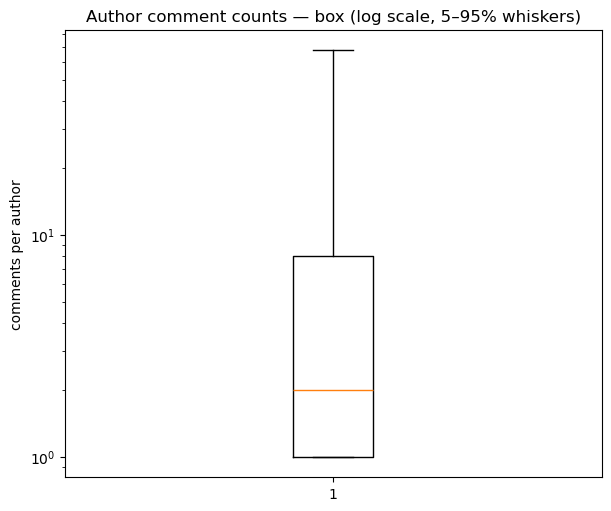

In [26]:
fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
ax.boxplot(s, showfliers=False, whis=(5, 95))  # whiskers at 5th–95th percentiles
ax.set_yscale("log")
ax.set_ylabel("comments per author")
ax.set_title("Author comment counts — box (log scale, 5–95% whiskers)")
plt.show()

## 2-Non-Negative Vector Factorization To Segment Commenters

In [3]:
def max_rows_that_fit(ram_gb=None, n=16, k=8, tfidf_copy=True, overhead=1.5, safe_frac=0.6):
    if ram_gb is None:
        ram_bytes = psutil.virtual_memory().total
    else:
        ram_bytes = ram_gb * (1024**3)
    copies = 2 if tfidf_copy else 1
    bytes_per_row = overhead * 4 * (n*copies + k)
    return int(safe_frac * ram_bytes // bytes_per_row), bytes_per_row

m_max, bpr = max_rows_that_fit(ram_gb=None, n=16, k=8) 
print(f"≈{m_max:,} rows fit safely (bytes/row≈{bpr:.0f})")


≈85,899,345 rows fit safely (bytes/row≈240)


In [5]:
src = base / "cats.csv.gz"
dst = base / "cats_30_filtered.csv.gz" 

chunksize = 600_000  
MIN_NUM_COMMENTS = 30 #keep rows with an author's # of comments > 30

first = True
total_kept = 0
for chunk in pd.read_csv(src, sep=",", compression="gzip", chunksize=chunksize, low_memory=False):
    # coerce ALL columns to numeric; non-numeric -> NaN -> 0
    num_chunk = chunk.apply(pd.to_numeric, errors="coerce").fillna(0)

    mask = num_chunk.sum(axis=1) > MIN_NUM_COMMENTS 
    kept = chunk.loc[mask]

    if not kept.empty:
        kept.to_csv(
            dst, index=False, compression="gzip",
            mode="wt" if first else "at", header=first
        )
        first = False
        total_kept += len(kept)

print(f"done. wrote {total_kept} rows to {dst.name}")

done. wrote 44648679 rows to cats_30_filtered.csv.gz


In [5]:
f = pd.read_csv(
    base /"cats_30_filtered.csv.gz", #subset of cats_filtered.csv.gz
    sep=",",
    compression="gzip",
)
print(f.shape)

(44648679, 16)


In [6]:
f.head(2)

,Unnamed: 0,Autos & Vehicles,Comedy,Education,Entertainment,Film & Animation,Gaming,Howto & Style,Music,News & Politics,Nonprofits & Activism,People & Blogs,Pets & Animals,Science & Technology,Sports,Travel & Events
0,0,0,34,6,83,2,570,5,38,5,0,31,0,3,0,0
1,0,0,1,5,12,0,0,0,16,1,0,5,6,0,0,5


In [7]:
f = f.rename({"Unnamed: 0":"no_category"},axis=1)

In [8]:
min(f.sum(axis=1))

31

coverage per column (lowest 5):
 no_category              0.001979
Nonprofits & Activism    0.369124
Autos & Vehicles         0.398034
Travel & Events          0.535589
Pets & Animals           0.580163
dtype: float64

coverage per column (highest 5):
 Film & Animation    0.943106
Music               0.951631
Comedy              0.961737
People & Blogs      0.989486
Entertainment       0.995114
dtype: float64

factor f0 top-6:
  Gaming                   30.1042
  Film & Animation         0.6638
  Entertainment            0.0813
  Pets & Animals           0.0674
  People & Blogs           0.0315
  Music                    0.0011

factor f1 top-6:
  Entertainment            24.8943
  Film & Animation         1.7601
  Education                0.6426
  Pets & Animals           0.2745
  Travel & Events          0.0836
  Nonprofits & Activism    0.0045

factor f2 top-6:
  News & Politics          18.0256
  Education                1.7378
  Nonprofits & Activism    0.4265
  Entertainment     

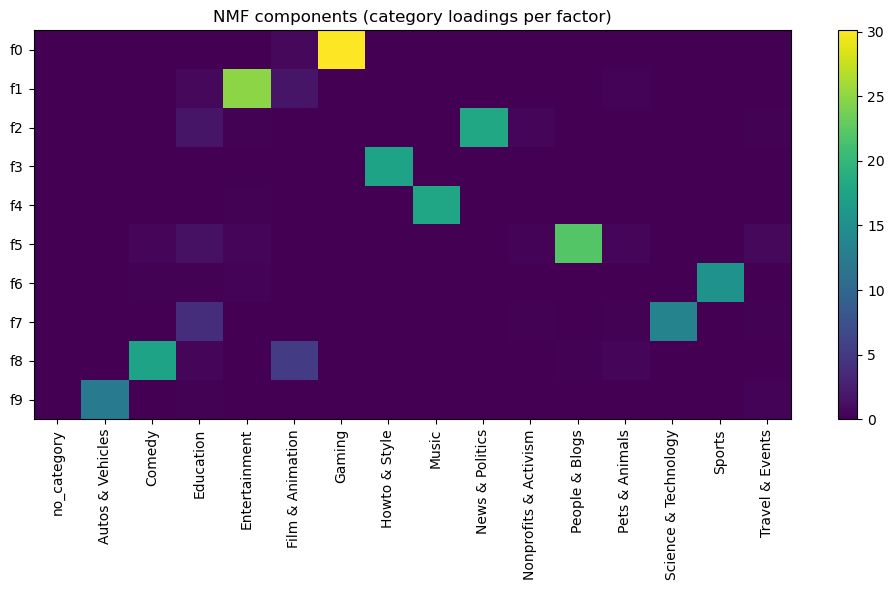

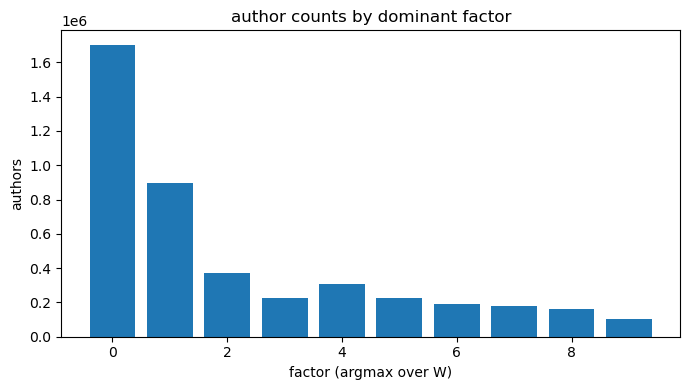

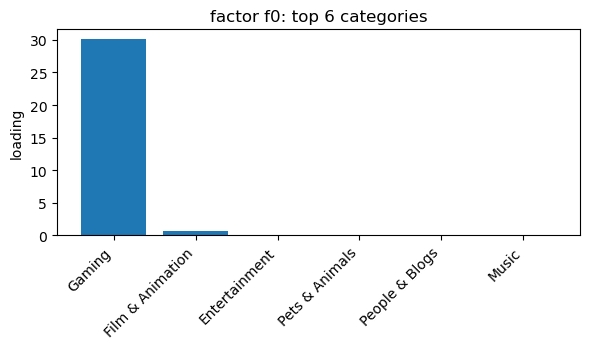

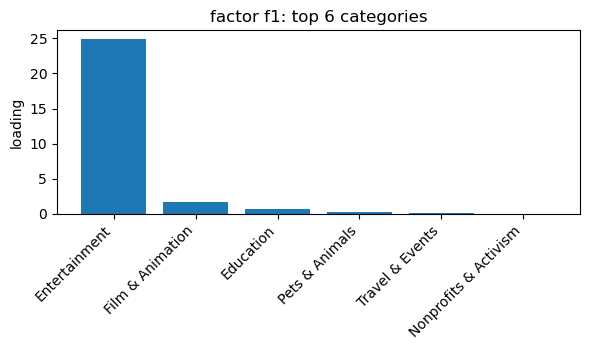

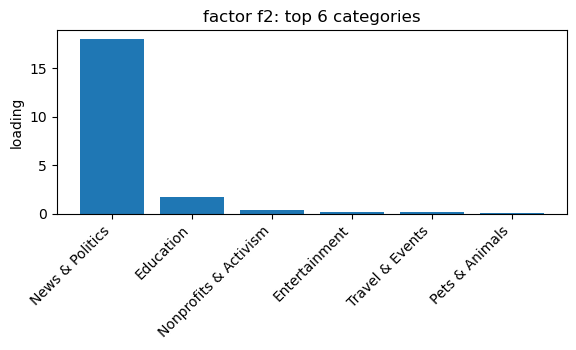

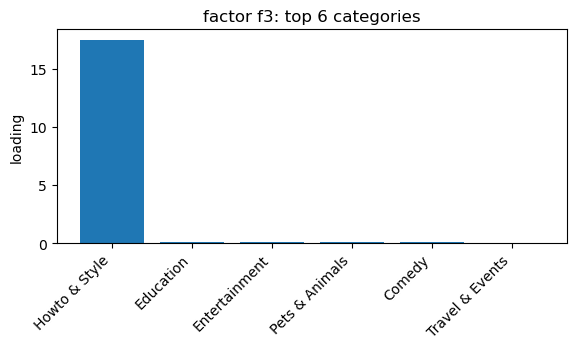

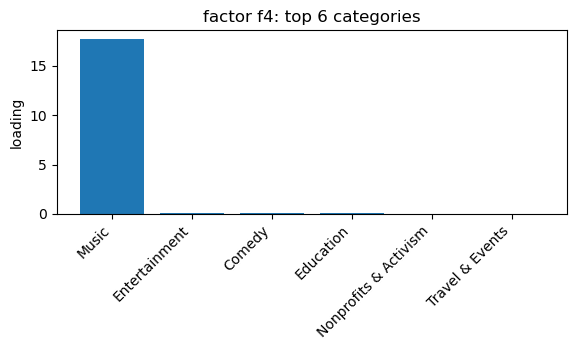

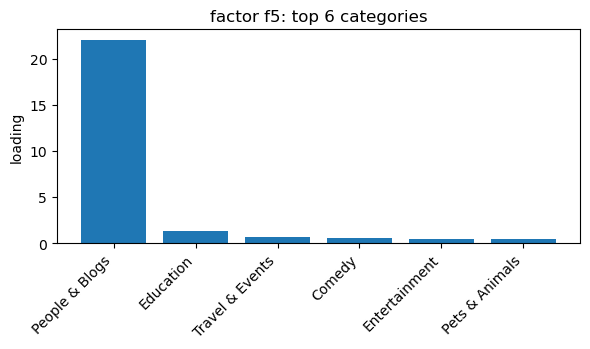

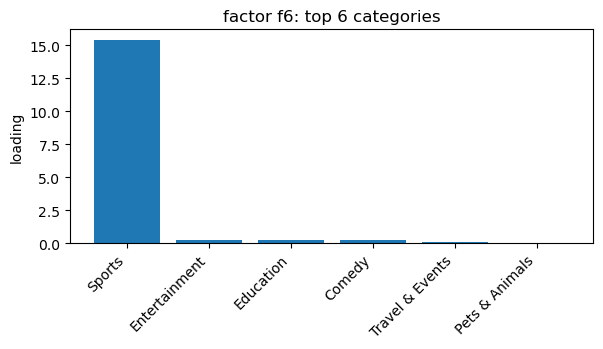

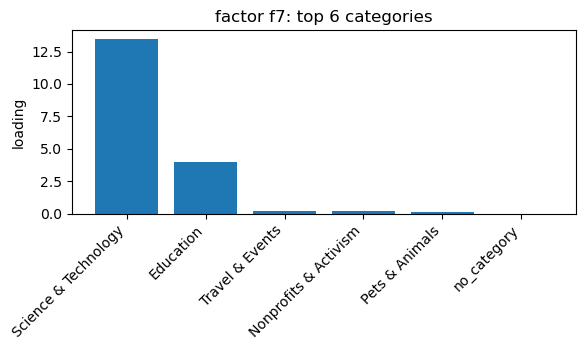

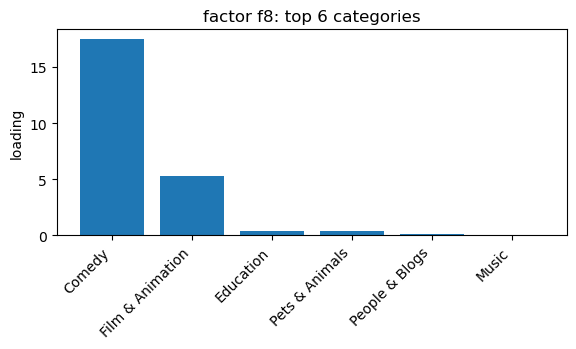

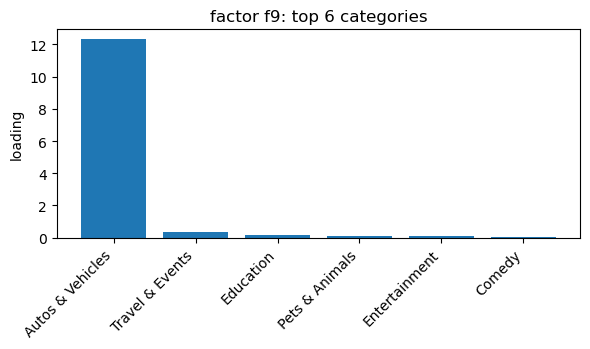

In [9]:
# ===== NMF on author × category counts (complete pipeline) =====
# --------------------------- config ----------------------------
USE_TFIDF     = False     # True = TF-IDF, False = raw counts; try both if curious
K_FACTORS     = 10        # good for now.
MIN_ROW_SUM   = 300        # drop authors with ≤300 total comments -need ram
DROP_UNIVERSAL= False     # drop columns commented by ~everyone (likely "total")
UNIVERSAL_THR = 0.98     # coverage threshold to drop if DROP_UNIVERSAL
DROP_RARE     = False    # optionally drop ultra-rare columns
RARE_THR      = 0        # coverage < 0.5% considered rare
RANDOM_STATE  = 0
# ---------------------------------------------------------------

#Check coverages per column.
G = f.select_dtypes(include="number").copy()
G = G[G.sum(axis=1) > MIN_ROW_SUM].copy()
coverage = (G > 0).mean(axis=0).sort_values()
print("coverage per column (lowest 5):\n", coverage.head(5))
print("\ncoverage per column (highest 5):\n", coverage.tail(5))

to_drop = []
if DROP_UNIVERSAL:
    to_drop += coverage[coverage >= UNIVERSAL_THR].index.tolist()
if DROP_RARE and RARE_THR is not None:
    to_drop += coverage[coverage <= RARE_THR].index.tolist()
to_drop = sorted(set(to_drop))
if to_drop:
    print("\ndropping columns due to coverage rule:", to_drop)
    G = G.drop(columns=to_drop)

cats = G.columns.tolist()
X = G.to_numpy(dtype=np.float32, copy=False)
np.nan_to_num(X, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

row_sums = X.sum(axis=1, keepdims=True)
TF = X / (row_sums + 1e-12)

if USE_TFIDF:
    n_rows = X.shape[0]
    df_counts = (X > 0).sum(axis=0).astype(np.float32)
    idf = np.log((1.0 + n_rows) / (1.0 + df_counts)) + 1.0
    Xw = TF * idf 
else:
    Xw = TF     

# -----------------------  fit NMF model (I'll update parameters :)) ----------------------
nmf = NMF(
    n_components=K_FACTORS,
    init="nndsvd",
    solver="cd",
    beta_loss="frobenius",
    max_iter=1400,
    tol=1e-4,
    random_state=0,
)

W = nmf.fit_transform(Xw).astype(np.float32) 
H = nmf.components_.astype(np.float32)       

# soft memberships as proportions (each row sums to 1)
W_sum = W.sum(axis=1, keepdims=True) + 1e-12
W_prop = (W / W_sum).astype(np.float32)
labels = W_prop.argmax(axis=1)

topn = 6
for i in range(H.shape[0]):
    idx = np.argsort(H[i])[::-1][:topn]
    print(f"\nfactor f{i} top-{topn}:")
    for j in idx:
        print(f"  {cats[j]:<24s} {H[i, j]:.4f}")
rep_n = 10
for i in range(H.shape[0]):
    reps = np.argsort(W_prop[:, i])[-rep_n:][::-1]
    print(f"\nrepresentative rows for f{i}: {reps.tolist()}")

plt.figure(figsize=(10, max(3, 0.6 * K_FACTORS)))
plt.imshow(H, aspect="auto")
plt.xticks(range(len(cats)), cats, rotation=90)
plt.yticks(range(K_FACTORS), [f"f{i}" for i in range(K_FACTORS)])
plt.title("NMF components (category loadings per factor)")
plt.colorbar()
plt.tight_layout()
plt.show()

counts = np.bincount(labels, minlength=K_FACTORS)
plt.figure(figsize=(7, 4))
plt.bar(range(K_FACTORS), counts)
plt.xlabel("factor (argmax over W)")
plt.ylabel("authors")
plt.title("author counts by dominant factor")
plt.tight_layout()
plt.show()

topk = 6
for i in range(H.shape[0]):
    idx = np.argsort(H[i])[::-1][:topk]
    plt.figure(figsize=(6, 3.6))
    plt.bar(range(topk), H[i, idx])
    plt.xticks(range(topk), [cats[j] for j in idx], rotation=45, ha="right")
    plt.ylabel("loading")
    plt.title(f"factor f{i}: top {topk} categories")
    plt.tight_layout()
    plt.show()
out = pd.DataFrame({
    "nmf_label": labels
}, index=G.index)
for i in range(K_FACTORS):
    out[f"f{i}"] = W_prop[:, i]

In [10]:
out.head()

,nmf_label,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9
0,0,0.678943,0.113580,0.010000,0.010305,0.077070,0.049210,0.000261,0.007870,0.052761,0.000000
37,0,0.559954,0.217020,0.001138,0.011769,0.104214,0.034200,0.000206,0.031502,0.039970,0.000027
53,4,0.184851,0.145913,0.028091,0.032124,0.333392,0.058794,0.000000,0.164273,0.052563,0.000000
67,3,0.000000,0.057259,0.000000,0.856408,0.038002,0.043791,0.000000,0.000000,0.004540,0.000000
78,3,0.000000,0.180300,0.000000,0.469710,0.203791,0.082639,0.003203,0.000642,0.059714,0.000000


In [11]:
from collections import Counter, defaultdict

# 1) pick top category per factor
top1_idx   = H.argmax(axis=1)                   # length = K_FACTORS
raw_names  = [cats[j] for j in top1_idx]        # e.g. ['sports','music',...]

# 2) make them unique iff duplicates exist
counts = Counter(raw_names)
seen   = defaultdict(int)
factor_names = []
for name in raw_names:
    seen[name] += 1
    if counts[name] > 1:
        factor_names.append(f"{name}#{seen[name]}")   # sports#1, sports#2, ...
    else:
        factor_names.append(name)

mem_cols = factor_names                              # length = K_FACTORS
M = pd.DataFrame(W_prop, columns=mem_cols, index=G.index)

label_idx   = labels
label_names = [factor_names[i] for i in label_idx]
out = pd.DataFrame(
    {"nmf_label": label_idx, "nmf_label_name": label_names},
    index=G.index
).join(M)

H_df = pd.DataFrame(H, columns=cats)
H_df.insert(0, "factor_name", factor_names)

In [12]:
H_df.factor_name.unique()

array(['Gaming', 'Entertainment', 'News & Politics', 'Howto & Style',
       'Music', 'People & Blogs', 'Sports', 'Science & Technology',
       'Comedy', 'Autos & Vehicles'], dtype=object)

In [13]:
out.head()

,nmf_label,nmf_label_name,Gaming,Entertainment,News & Politics,Howto & Style,Music,People & Blogs,Sports,Science & Technology,Comedy,Autos & Vehicles
0,0,Gaming,0.678943,0.113580,0.010000,0.010305,0.077070,0.049210,0.000261,0.007870,0.052761,0.000000
37,0,Gaming,0.559954,0.217020,0.001138,0.011769,0.104214,0.034200,0.000206,0.031502,0.039970,0.000027
53,4,Music,0.184851,0.145913,0.028091,0.032124,0.333392,0.058794,0.000000,0.164273,0.052563,0.000000
67,3,Howto & Style,0.000000,0.057259,0.000000,0.856408,0.038002,0.043791,0.000000,0.000000,0.004540,0.000000
78,3,Howto & Style,0.000000,0.180300,0.000000,0.469710,0.203791,0.082639,0.003203,0.000642,0.059714,0.000000


### 2.1 Creating Subclusters from NMF result

In [15]:
"""
Given an NMF membership table `out`:

1) Identify each row’s top-1 and top-2 factor (names and weights) from the
   factor-weight columns (exclude ['nmf_label','nmf_label_name']).
2) Tag each row:
   - if top1_weight ≥ 0.55 → "<Top1> core"
   - elif top2_weight ≥ 0.20 → "<Top1>+<Top2>"
   - else → "<Top1> mixed"
3) Write back to `out`:
   - out['subcat'], out['top1_weight'], out['top2_weight'], out['top2_name']
4) Print frequency of the resulting subcategory tags.
"""

label_cols = ["nmf_label", "nmf_label_name"]
mem_cols   = [c for c in out.columns if c not in label_cols]

W = out[mem_cols].to_numpy()
top2_idx = np.argsort(W, axis=1)[:, -2:]            
top1_i   = top2_idx[:, 1]
top2_i   = top2_idx[:, 0]
top1_w   = W[np.arange(W.shape[0]), top1_i]
top2_w   = W[np.arange(W.shape[0]), top2_i]
top1_n   = np.array(mem_cols)[top1_i]
top2_n   = np.array(mem_cols)[top2_i]

TAU_PRIMARY = 0.55
TAU_SECOND  = 0.20

subcat = np.where(
    top1_w >= TAU_PRIMARY,
    top1_n + " core",
    np.where(
        top2_w >= TAU_SECOND,
        (top1_n + "+" + top2_n),
        top1_n + " mixed"  # neither strong primary nor strong second
    ),
)

out["subcat"]       = subcat
out["top1_weight"]  = top1_w
out["top2_weight"]  = top2_w
out["top2_name"]    = top2_n
print(out["subcat"].value_counts().head(20))

subcat
Gaming core                      672403
Gaming+Entertainment             403287
Gaming mixed                     349536
Entertainment mixed              226485
Entertainment+Gaming             169463
News & Politics core             160457
Entertainment core               109143
Entertainment+People & Blogs     100849
Entertainment+Comedy              97062
Howto & Style core                92385
Music core                        86766
Music+Entertainment               84767
Gaming+Comedy                     82743
News & Politics mixed             82407
Entertainment+Music               77858
People & Blogs+Entertainment      68805
Comedy+Entertainment              65751
Sports core                       62515
News & Politics+Entertainment     59880
Gaming+Music                      58824
Name: count, dtype: int64


   orig_index                                         top_counts  \
0    29600052  Entertainment:537, no_category:0, Autos & Vehi...   
1    38516968  Entertainment:407, no_category:0, Autos & Vehi...   
2    40176544  Entertainment:868, no_category:0, Autos & Vehi...   
3    24923586  Entertainment:527, no_category:0, Autos & Vehi...   
4    38595444  Entertainment:393, no_category:0, Autos & Vehi...   
5    14862626  Entertainment:16568, People & Blogs:2, no_cate...   
6     7623247  Entertainment:359, no_category:0, Autos & Vehi...   
7    10057024  Entertainment:522, Film & Animation:1, no_cate...   
8     3931988  Entertainment:638, no_category:0, Autos & Vehi...   
9     9353885  Entertainment:2133, no_category:0, Autos & Veh...   

                                           top_props  
0  Entertainment:1.00, no_category:0.00, Autos & ...  
1  Entertainment:1.00, no_category:0.00, Autos & ...  
2  Entertainment:1.00, no_category:0.00, Autos & ...  
3  Entertainment:1.00, no_categ

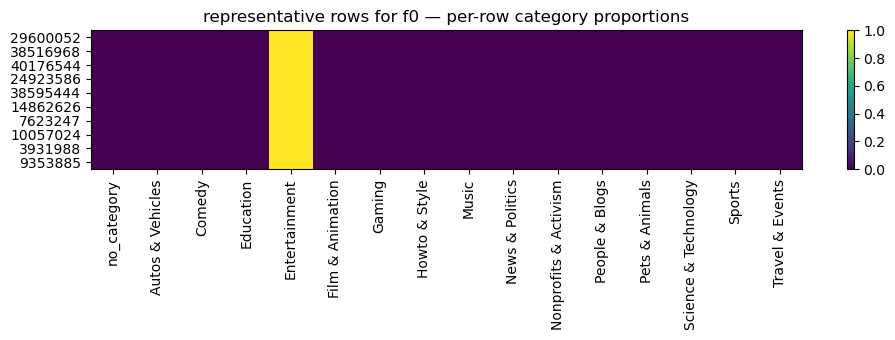

In [16]:
# ourr representative positions for factor 0: TO SEE SOME ROWS AND UNDERSTAND THEM.
pos = np.array([2894263, 3765422, 3927392, 2437632, 3773169, 1454325, 746633, 984564, 386102, 915680])

orig_idx = G.index.to_numpy()[pos]     
rows_f = f.loc[orig_idx]          
rows_G = G.iloc[pos]               

cats = rows_G.columns.tolist()
props = rows_G.div(rows_G.sum(axis=1), axis=0)

def topk_counts(s, k=5):
    s = s.astype(float)
    top = s.sort_values(ascending=False).head(k)
    return ", ".join(f"{c}:{int(v)}" for c,v in top.items())

def topk_props(s, k=5):
    top = s.sort_values(ascending=False).head(k)
    return ", ".join(f"{c}:{v:.2f}" for c,v in top.items())

summary = pd.DataFrame({
    "orig_index": orig_idx,
    "top_counts": [topk_counts(rows_G.iloc[i]) for i in range(len(pos))],
    "top_props":  [topk_props(props.iloc[i])   for i in range(len(pos))]
})
print(summary)

weights = pd.DataFrame(W_prop[pos], columns=[f"f{i}" for i in range(W_prop.shape[1])], index=orig_idx)
weights = weights.sort_values("f0", ascending=False)
print(weights.head(10))
plt.figure(figsize=(10, 3.5))
plt.imshow(props.to_numpy(), aspect="auto")
plt.xticks(range(len(cats)), cats, rotation=90)
plt.yticks(range(len(pos)), [str(i) for i in orig_idx])
plt.title("representative rows for f0 — per-row category proportions")
plt.colorbar()
plt.tight_layout()
plt.show()

if 'author_id' in f.columns:
    ids = f.loc[orig_idx, 'author_id']
    view = pd.concat([ids.rename('author_id'), weights], axis=1)
    print(view.head(10))

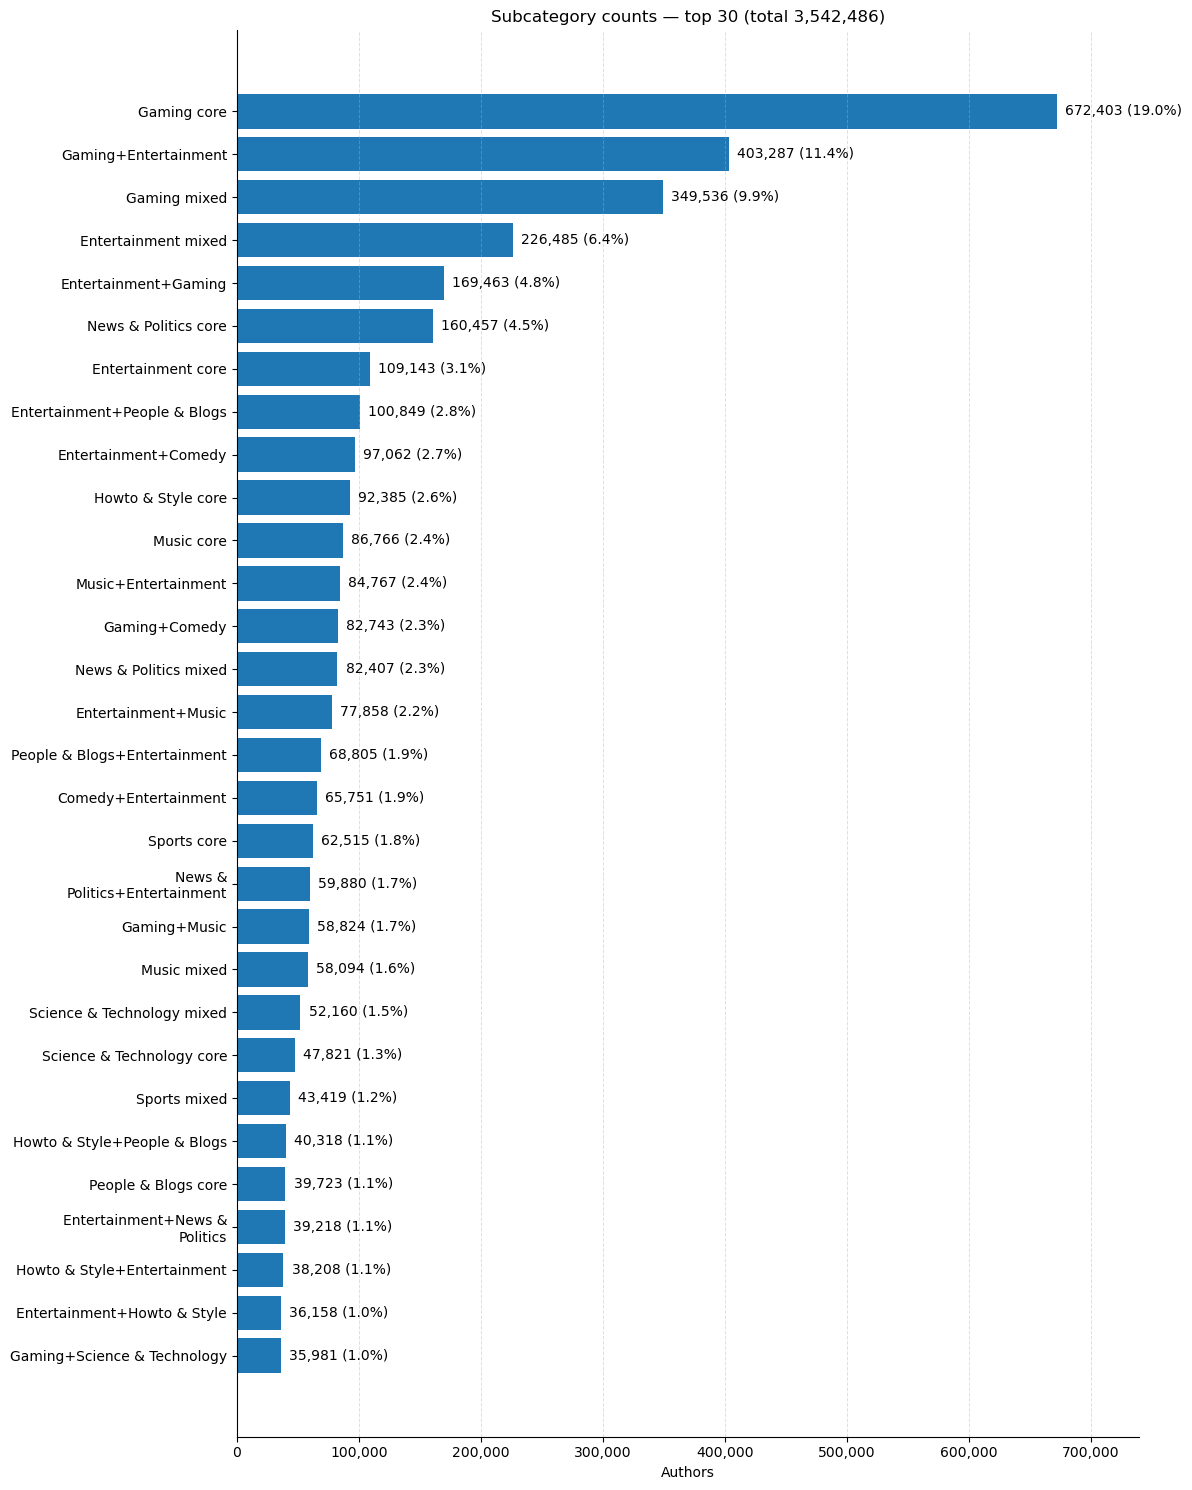

In [17]:
s = (out["subcat"].dropna().value_counts().sort_values(ascending=False))
top_n = 30
s = s.head(top_n)

labels = ["\n".join(textwrap.wrap(str(lbl), width=28)) for lbl in s.index]
total = int(s.sum())
fig_h = max(4, 0.45 * len(s) + 1.5)

fig, ax = plt.subplots(figsize=(12, fig_h))
bars = ax.barh(labels, s.values)
ax.invert_yaxis()
ax.set_xlim(0, s.values.max() * 1.1)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
ax.set_xlabel("Authors")
ax.set_title(f"Subcategory counts — top {len(s)} (total {total:,})")

for bar, v in zip(bars, s.values):
    ax.text(v + s.values.max()*0.01, bar.get_y() + bar.get_height()/2,
            f"{int(v):,} ({v/total:.1%})", va="center", ha="left")

ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.4)
for spine in ("top","right"):
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

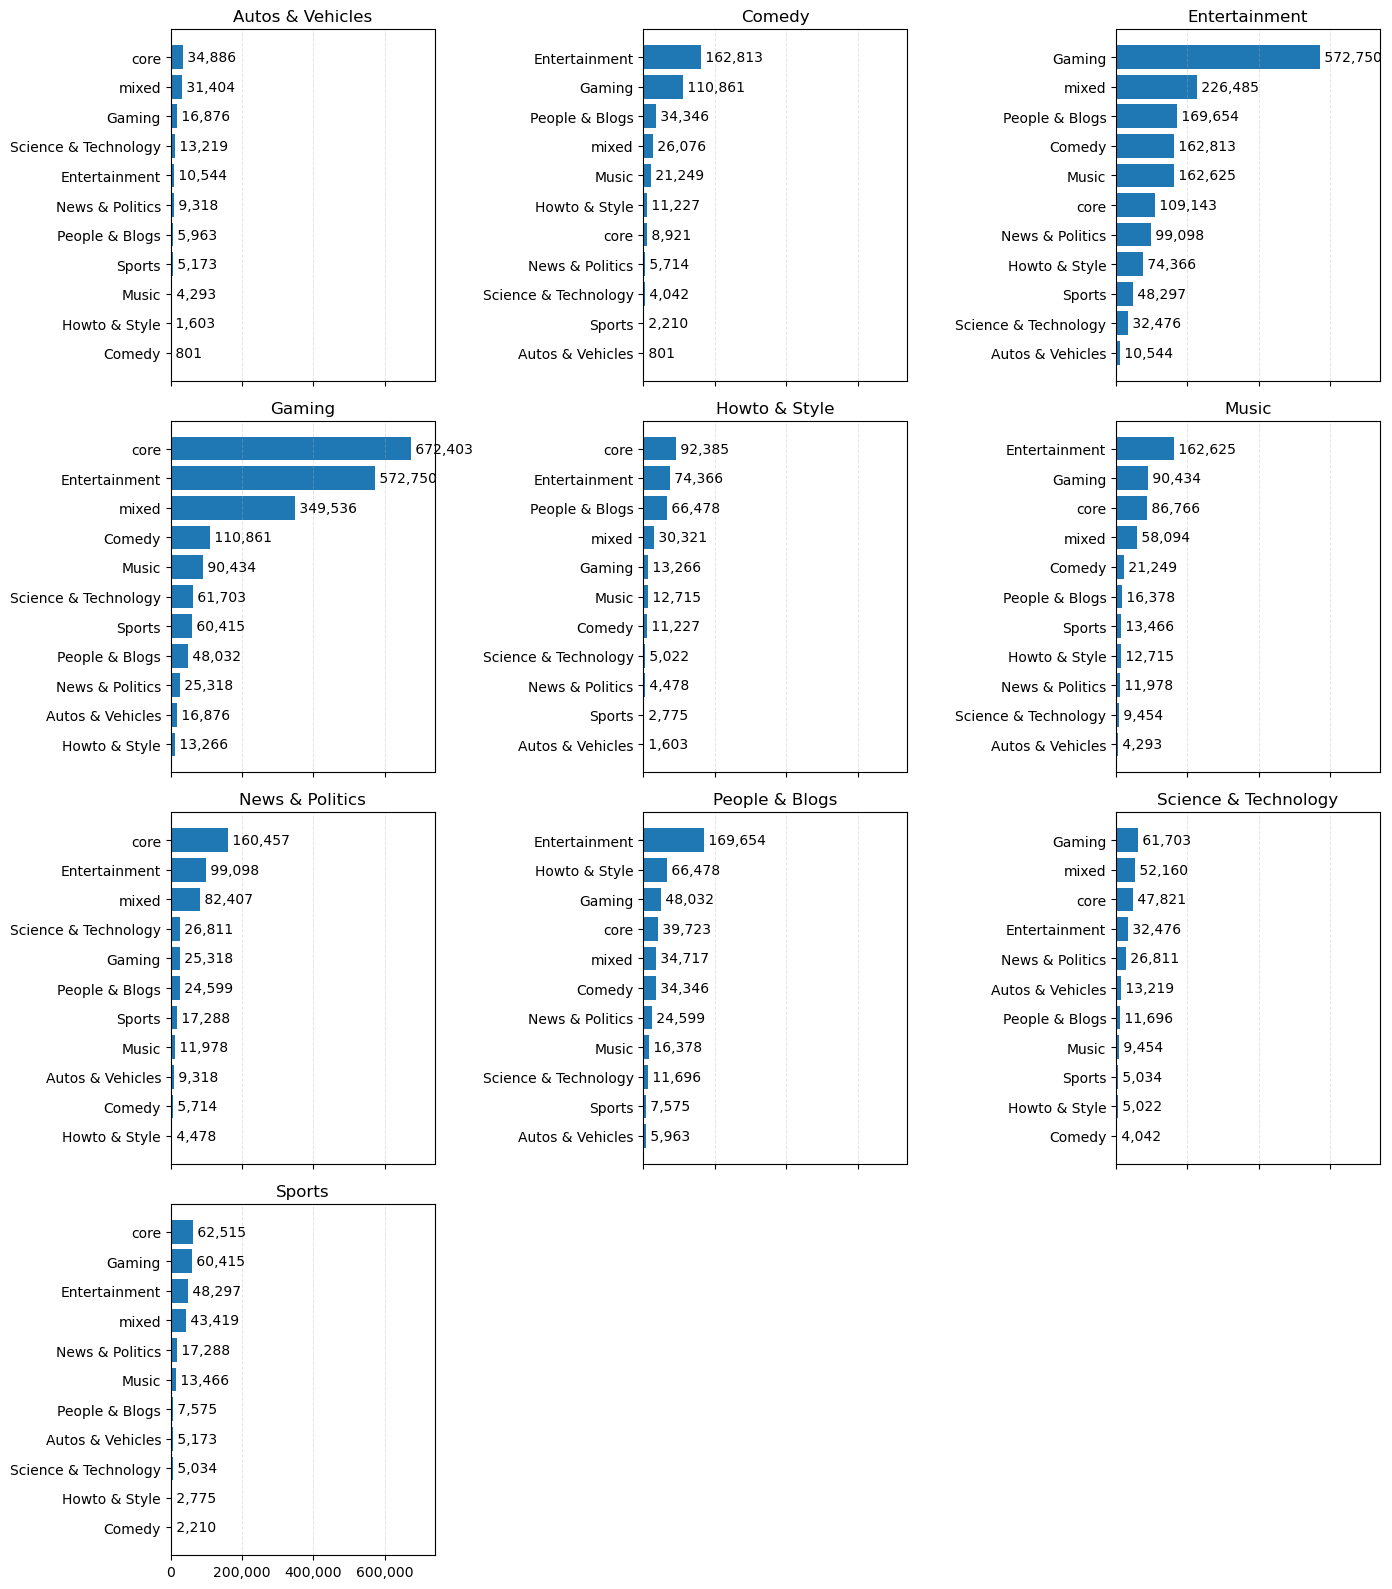

In [18]:
s = out["subcat"].dropna().value_counts()

def parse_cats(label):
    base = re.sub(r"\s+(core|mixed)\s*$", "", str(label)).strip()
    return [p.strip() for p in base.split("+")]
mains = sorted({c for lbl in s.index for c in parse_cats(lbl)})

def counts_for(main, series):
    d = {}
    c = series.get(f"{main} core", 0)
    m = series.get(f"{main} mixed", 0)
    if c: d["core"] = int(c)
    if m: d["mixed"] = int(m)
    pairs = series[series.index.str.contains(r"\+", regex=True)]
    for lbl, cnt in pairs.items():
        cats = parse_cats(lbl)
        if main in cats and len(cats) == 2:
            other = cats[0] if cats[1] == main else cats[1]
            d[other] = d.get(other, 0) + int(cnt)
    return pd.Series(d, dtype="float64")

top_k = 12
series_list = []
max_x = 0
for main in mains:
    ser = counts_for(main, s)
    if ser.empty:
        continue
    ser = ser.sort_values(ascending=False).head(top_k).sort_values(ascending=True)
    series_list.append((main, ser))
    if ser.max() > max_x:
        max_x = float(ser.max())

cols = 3
rows = (len(series_list) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax in axes:
    ax.axis("off")

for ax, (main, ser) in zip(axes, series_list):
    ax.axis("on")
    bars = ax.barh(ser.index, ser.values)
    ax.set_title(main)
    ax.set_xlim(0, max_x * 1.1)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
    for b, v in zip(bars, ser.values):
        ax.text(v, b.get_y() + b.get_height() / 2, f" {int(v):,}", va="center")
    ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.35)

plt.tight_layout()
plt.show()

## 3-Data Enrichment -> Understand Inactive Channels

In [64]:
import os
os.environ["YT_API_KEY"] = "YT_API_KEY"

In [34]:
df_channels = pd.read_csv(base / "df_channels_en.tsv.gz", sep="\t")
print("channels preview:", df_channels.shape)

channels preview: (136470, 8)


In [36]:
df_channels.head() #unique channel list 137K channels

,category_cc,join_date,channel,name_cc,subscribers_cc,videos_cc,subscriber_rank_sb,weights
0,Gaming,2010-04-29,UC-lHJZR3Gqxm24_Vd_AJ5Yw,PewDiePie,101000000,3956,3.0,2.087
1,Education,2006-09-01,UCbCmjCuTUZos6Inko4u57UQ,Cocomelon - Nursery ...,60100000,458,7.0,2.087
2,Entertainment,2006-09-20,UCpEhnqL0y41EpW2TvWAHD7Q,SET India,56018869,32661,8.0,2.087
3,Howto & Style,2016-11-15,UC295-Dw_tDNtZXFeAPAW6Aw,5-Minute Crafts,60600000,3591,9.0,2.087
4,Sports,2007-05-11,UCJ5v_MCY6GNUBTO8-D3XoAg,WWE,48400000,43421,11.0,2.087


In [38]:
round(df_channels.category_cc.value_counts(normalize=True),2)*100

category_cc
Music                    18.0
Entertainment            17.0
Gaming                   15.0
People & Blogs           14.0
Howto & Style             9.0
Education                 6.0
Film and Animation        5.0
Sports                    4.0
Science & Technology      4.0
Comedy                    3.0
Autos & Vehicles          3.0
News & Politics           2.0
Travel & Events           1.0
Pets & Animals            1.0
Nonprofits & Activism     1.0
Name: proportion, dtype: float64

In [40]:
#Take stratified weighted sample because youtube API quota limit.
def stratified_weighted_sample(
    df: pd.DataFrame,
    strat_col: str = "category_cc",
    weight_col: str | None = "weights",
    n: int | None = None,
    frac: float | None = None,
    ratio_basis: str = "count",      # "count" keeps the by-count category ratio; "weight_sum" keeps share by sum(weights)
    min_per_stratum: int = 1,
    random_state: int | None = 42,
) -> pd.DataFrame:
    if (n is None) == (frac is None):
        raise ValueError("Specify exactly one of n or frac.")
    if frac is not None:
        if not (0 < frac <= 1):
            raise ValueError("frac must be in (0, 1].")
        n = max(1, int(round(frac * len(df))))

    rng = np.random.default_rng(random_state)

    if ratio_basis == "count":
        base_sizes = df[strat_col].value_counts().sort_index()
    elif ratio_basis == "weight_sum":
        if weight_col is None:
            raise ValueError("ratio_basis='weight_sum' requires weight_col.")
        base_sizes = df.groupby(strat_col)[weight_col].sum().sort_index()
    else:
        raise ValueError("ratio_basis must be 'count' or 'weight_sum'.")

    props = base_sizes / base_sizes.sum()
    raw = props * n
    alloc = np.floor(raw).astype(int)

    for cat in base_sizes.index:
        alloc[cat] = max(alloc[cat], min_per_stratum)

    remainder = n - alloc.sum()
    if remainder != 0:
        frac_part = (raw - np.floor(raw)).rename("frac")
        order = frac_part.sample(frac=1.0, random_state=random_state).sort_values(ascending=remainder>0)
        for cat in order.index:
            if remainder == 0: break
            step = 1 if remainder > 0 else -1
            if step < 0 and alloc[cat] <= min_per_stratum: 
                continue
            alloc[cat] += step
            remainder -= step

    groups = []
    for cat, k in alloc.items():
        g = df[df[strat_col] == cat]
        if k <= 0 or g.empty:
            continue
        replace = k > len(g)
        if weight_col and weight_col in g.columns:
            w = pd.to_numeric(g[weight_col], errors="coerce").clip(lower=0).fillna(0)
            if (w > 0).sum() == 0:
                w = None
        else:
            w = None
        groups.append(g.sample(n=k, replace=replace, weights=w, random_state=random_state))
    if not groups:
        return df.iloc[0:0].copy()
    return pd.concat(groups, axis=0).sample(frac=1.0, random_state=random_state).reset_index(drop=True)

In [42]:
sample_10pct = stratified_weighted_sample(
    df_channels, strat_col="category_cc", weight_col="weights", frac=0.02, ratio_basis="count", random_state=123
)

In [44]:
sample_10pct.shape

(2729, 8)

In [46]:
round(df_channels.category_cc.value_counts(normalize=True),2)*100

category_cc
Music                    18.0
Entertainment            17.0
Gaming                   15.0
People & Blogs           14.0
Howto & Style             9.0
Education                 6.0
Film and Animation        5.0
Sports                    4.0
Science & Technology      4.0
Comedy                    3.0
Autos & Vehicles          3.0
News & Politics           2.0
Travel & Events           1.0
Pets & Animals            1.0
Nonprofits & Activism     1.0
Name: proportion, dtype: float64

In [47]:
round(sample_10pct.category_cc.value_counts(normalize=True),2)*100

category_cc
Music                    18.0
Entertainment            17.0
Gaming                   15.0
People & Blogs           13.0
Howto & Style             9.0
Education                 6.0
Film and Animation        5.0
Sports                    4.0
Science & Technology      4.0
Comedy                    3.0
Autos & Vehicles          3.0
News & Politics           2.0
Travel & Events           1.0
Pets & Animals            1.0
Nonprofits & Activism     1.0
Name: proportion, dtype: float64

In [50]:
import os, re, time, requests, pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

API_KEY = os.getenv("YT_API_KEY") or globals().get("API_KEY", "")
BASE = "https://www.googleapis.com/youtube/v3"
VID_RE = re.compile(r'^[A-Za-z0-9_-]{11}$')

def _extract_vid(x):
    if x is None: return None
    s = str(x).strip()
    if VID_RE.fullmatch(s): return s
    m = re.search(r'(?:v=)([A-Za-z0-9_-]{11})', s) or re.search(r'(youtu\.be/|/embed/|/shorts/)([A-Za-z0-9_-]{11})', s)
    return (m.group(1 if m.lastindex==1 else 2)) if m else None

def _oembed_status(vid):
    try:
        r = requests.get("https://www.youtube.com/oembed",
                         params={"url": f"https://www.youtube.com/watch?v={vid}", "format":"json"},
                         timeout=10)
        if r.status_code == 200:  return "ok"
        if r.status_code == 401:  return "private"
        if r.status_code in (404,410): return "removed"
        return f"http_{r.status_code}"
    except Exception:
        return "error"

def get_video_title_and_status(video_ids, api_key):
    ids = pd.Series(video_ids).dropna().astype(str).map(_extract_vid).dropna().unique().tolist()
    rows, missing = [], []
    with requests.Session() as s:
        for i in range(0, len(ids), 50):
            chunk = ids[i:i+50]
            r = s.get(f"{BASE}/videos", params={"part":"snippet,status","id":",".join(chunk),"key":api_key}, timeout=20)
            r.raise_for_status()
            items = {it["id"]: it for it in r.json().get("items", [])}
            for vid in chunk:
                it = items.get(vid)
                if not it:
                    missing.append(vid); continue
                title = (it.get("snippet") or {}).get("title")
                privacy = (it.get("status") or {}).get("privacyStatus")
                status = "ok" if privacy in ("public","unlisted") else ("private" if privacy=="private" else "unknown")
                rows.append({"video_id": vid, "video_title": title, "yt_status": status})
            time.sleep(0.03)
    for vid in missing:
        rows.append({"video_id": vid, "video_title": None, "yt_status": _oembed_status(vid)})
    out = pd.DataFrame(rows)
    if out.empty:
        out = pd.DataFrame(columns=["video_id","video_title","yt_status","is_available"])
    out["is_available"] = out["yt_status"].eq("ok")
    return out

def _uploads_playlist_ids(channel_ids, api_key):
    ids = pd.Series(channel_ids).dropna().astype(str).unique().tolist()
    out = {}
    with requests.Session() as s:
        for i in range(0, len(ids), 50):
            chunk = ids[i:i+50]
            r = s.get(f"{BASE}/channels", params={"part":"contentDetails","id":",".join(chunk),"key":api_key}, timeout=20)
            r.raise_for_status()
            for it in r.json().get("items", []):
                out[it["id"]] = it["contentDetails"]["relatedPlaylists"]["uploads"]
            time.sleep(0.03)
    return out

def _latest_from_uploads(pid, api_key):
    r = requests.get(f"{BASE}/playlistItems",
                     params={"part":"contentDetails,snippet","playlistId":pid,"maxResults":50,"key":api_key},
                     timeout=20)
    if not r.ok: return None, pd.NaT, None
    items = r.json().get("items", [])
    best = None
    for it in items:
        sn = it.get("snippet") or {}
        cd = it.get("contentDetails") or {}
        vid = cd.get("videoId") or (sn.get("resourceId") or {}).get("videoId")
        ts = cd.get("videoPublishedAt") or sn.get("publishedAt")
        title = sn.get("title")
        if not (vid and ts): continue
        ts = pd.to_datetime(ts, utc=True, errors="coerce")
        if pd.isna(ts): continue
        if best is None or ts > best[0]:
            best = (ts, vid, title)
    if not best: return None, pd.NaT, None
    return best[1], best[0], best[2]

def get_channels_latest_bulk(channel_ids, api_key, tz="Europe/Zurich", workers=32):
    ch2pid = _uploads_playlist_ids(channel_ids, api_key)
    recs = []
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futs = {ex.submit(_latest_from_uploads, pid, api_key): cid for cid, pid in ch2pid.items() if pd.notna(pid)}
        for f in as_completed(futs):
            cid = futs[f]
            try:
                vid, ts_utc, title = f.result()
            except Exception:
                vid, ts_utc, title = None, pd.NaT, None
            recs.append({"channel_id": cid, "last_video_id": vid, "last_upload_utc": ts_utc, "last_video_title": title})
    out = pd.DataFrame(recs)
    if out.empty:
        out = pd.DataFrame(columns=["channel_id","last_video_id","last_upload_utc","last_video_title","last_upload_local"])
    out["last_upload_utc"] = pd.to_datetime(out["last_upload_utc"], utc=True, errors="coerce")
    out["last_upload_local"] = out["last_upload_utc"].dt.tz_convert(tz)
    return out

def extend_dataframe_with_titles_status_and_latest(b: pd.DataFrame, api_key: str, tz="Europe/Zurich") -> pd.DataFrame:
    df = b.copy()
    if "video_id" not in df.columns and "display_id" in df.columns:
        df = df.rename(columns={"display_id":"video_id"})
    if "video_id" in df.columns:
        vdf = get_video_title_and_status(df["video_id"], api_key)
        df = df.merge(vdf, on="video_id", how="left")
    if "channel_id" in df.columns:
        cdf = get_channels_latest_bulk(df["channel_id"], api_key, tz=tz)
        df = df.merge(cdf[["channel_id","last_upload_utc","last_upload_local","last_video_title"]], on="channel_id", how="left")
    return df

In [52]:
df_activ_check = sample_10pct.copy()
del sample_10pct

In [54]:
df_activ_check = df_activ_check.rename({"channel":"channel_id"},axis=1)

In [56]:
df_activ_check = extend_dataframe_with_titles_status_and_latest(df_activ_check, API_KEY, tz="Europe/Zurich")

In [58]:
df_activ_check.sample(5)

,category_cc,join_date,channel_id,name_cc,subscribers_cc,videos_cc,subscriber_rank_sb,weights,last_upload_utc,last_upload_local,last_video_title
1001,Music,2012-08-12,UCoqI6rd63GwtIgI3opxcQKw,Lunarity,18385,746,603046.0,10.8875,2025-04-13 08:32:11+00:00,2025-04-13 10:32:11+02:00,LUM!NA - Violet Desert
86,Film and Animation,2012-11-18,UCgZumu-Gmhrw4xglMBtsRmg,TheSaladShow,34000,87,369294.0,8.6625,2025-11-01 12:01:00+00:00,2025-11-01 13:01:00+01:00,We Dated But I Was His Sister! [ENG SUB] - Kad...
80,Entertainment,2017-01-18,UCembJ_FCOc0Xd6bJZC0v_xw,Loaf Tube,20600,265,402337.0,8.0390,2025-11-03 23:23:21+00:00,2025-11-04 00:23:21+01:00,Charlie Kirk’s Parents Drop BOMBSHELL About Er...
216,People & Blogs,2017-04-30,UCmB2dHRsHYXKRgf0wX3UrrQ,Food & Life,14900,330,535837.0,9.3415,2025-11-02 01:25:00+00:00,2025-11-02 02:25:00+01:00,Solan mallroad HP #shorts #youtubeshorts #sol...
1549,News & Politics,2009-02-12,UC2mV9iRa_9y_oXTHFH1ihgA,Paul McGuire,21000,1210,555705.0,9.6110,2025-11-04 00:31:46+00:00,2025-11-04 01:31:46+01:00,💥 TPMR 11/04/25 | DEMONIC POSSESSION & PSYCHOL...


              category_cc activity_band  n_channels
0        Autos & Vehicles        active          35
1        Autos & Vehicles  a_bit_active          11
2        Autos & Vehicles    not_active          29
3                  Comedy        active          18
4                  Comedy  a_bit_active          14
5                  Comedy    not_active          43
6               Education        active          64
7               Education  a_bit_active          19
8               Education    not_active          74
9           Entertainment        active         151
10          Entertainment  a_bit_active          60
11          Entertainment    not_active         248
12     Film and Animation        active          23
13     Film and Animation  a_bit_active          22
14     Film and Animation    not_active          92
15                 Gaming        active         114
16                 Gaming  a_bit_active          58
17                 Gaming    not_active         232
18          

/var/folders/4f/lgs40nxd3g3890_f8lsh6s8c0000gp/T/ipykernel_33329/950593111.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = (df.groupby(["category_cc","activity_band"], dropna=False)


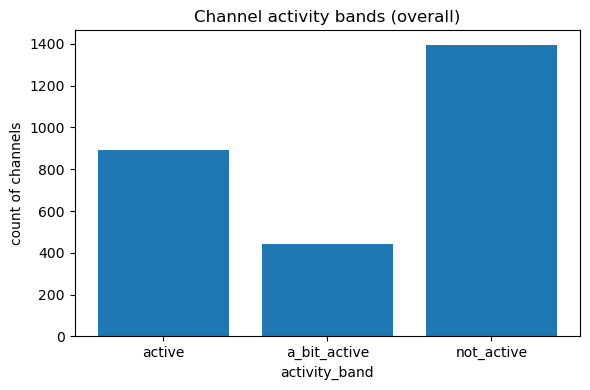

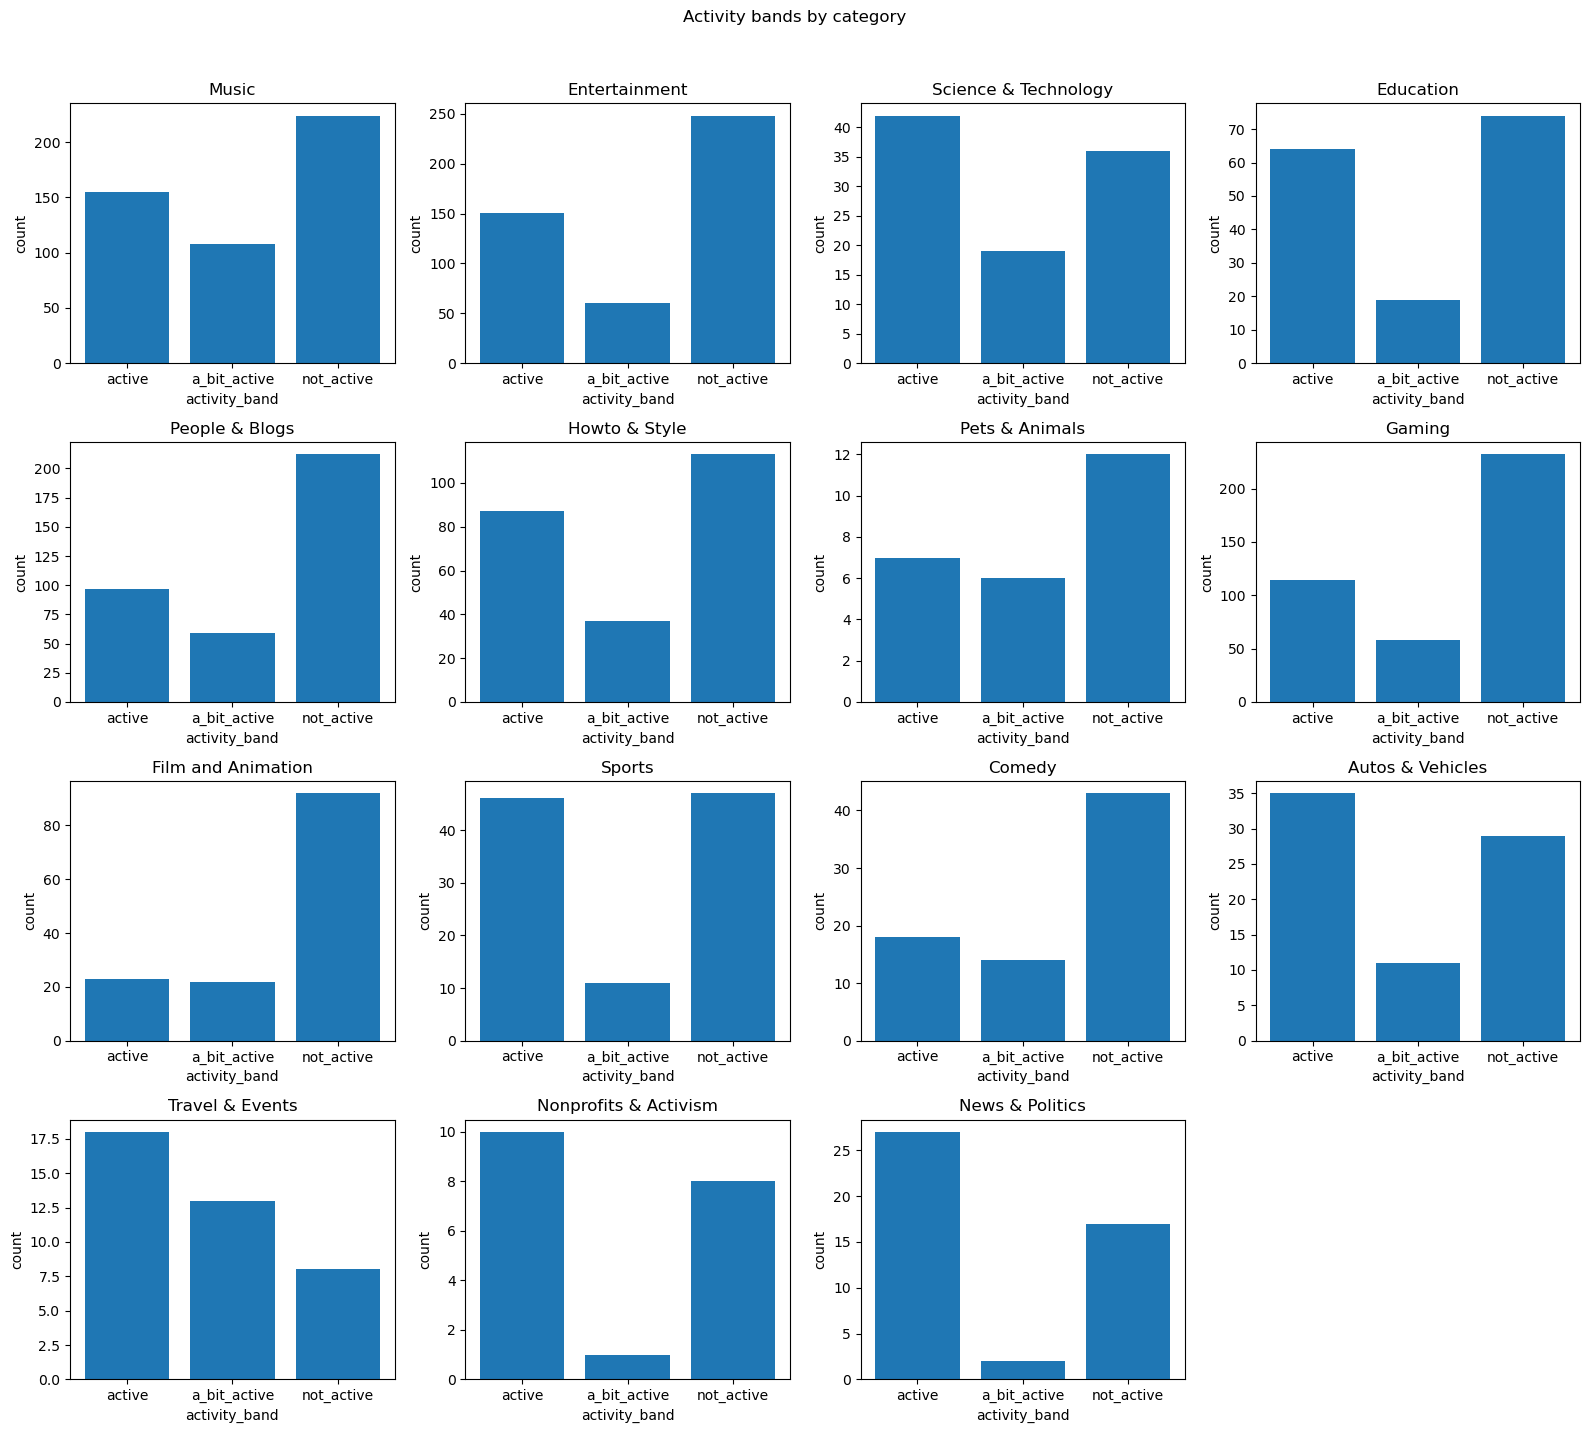

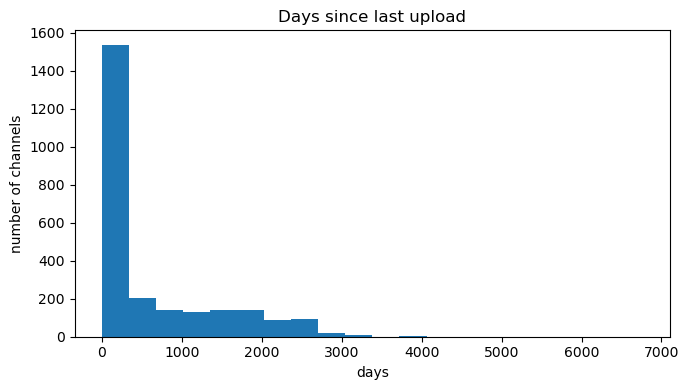

In [60]:
# ---- 1) start from your DataFrame ----
# Expect columns: category_cc, channel_id, last_upload_utc
df = df_activ_check.copy()

# ---- 2) normalize timestamps & compute activity metrics ----
df["last_upload_utc"] = pd.to_datetime(df["last_upload_utc"], utc=True, errors="coerce")
now_utc = pd.Timestamp.now(tz="UTC")
df["days_since_last_upload"] = (now_utc - df["last_upload_utc"]).dt.total_seconds() / 86400
df["days_since_last_upload"] = df["days_since_last_upload"].clip(lower=0)

bins = [-np.inf, 30, 180, np.inf]
labels = ["active", "a_bit_active", "not_active"]
df["activity_band"] = pd.cut(df["days_since_last_upload"], bins=bins, labels=labels)
df.loc[df["last_upload_utc"].isna(), "activity_band"] = "not_active"
df["current_30d"] = df["days_since_last_upload"] <= 30

# ---- 3) summary table (current number of channels by category & band) ----
summary = (df.groupby(["category_cc","activity_band"], dropna=False)
             .size()
             .reset_index(name="n_channels")
             .sort_values(["category_cc","activity_band"]))
print(summary)

# ---- 4) plots ----
# overall activity
order = ["active","a_bit_active","not_active"]
overall = df["activity_band"].value_counts().reindex(order).fillna(0)
plt.figure(figsize=(6,4))
plt.bar(overall.index.astype(str), overall.values)
plt.title("Channel activity bands (overall)")
plt.xlabel("activity_band")
plt.ylabel("count of channels")
plt.tight_layout()
plt.show()

# subplots by category: bar of activity bands per category
cats = df["category_cc"].dropna().astype(str).unique().tolist()
n = len(cats)
ncols = min(4, max(1, n))
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 3.5*nrows), squeeze=False)
for i, cat in enumerate(cats):
    r, c = divmod(i, ncols)
    ax = axes[r][c]
    sub = df[df["category_cc"] == cat]
    counts = sub["activity_band"].value_counts().reindex(order).fillna(0)
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(cat)
    ax.set_xlabel("activity_band")
    ax.set_ylabel("count")
# hide any empty axes
for j in range(n, nrows*ncols):
    r, c = divmod(j, ncols)
    axes[r][c].axis("off")
fig.suptitle("Activity bands by category", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

#histogram of recency
plt.figure(figsize=(7,4))
plt.hist(df["days_since_last_upload"].dropna().values, bins=20)
plt.title("Days since last upload")
plt.xlabel("days")
plt.ylabel("number of channels")
plt.tight_layout()
plt.show()


=== Subscribers by activity_band ===
activity_band    n  median     p25     p75
       active  894 28300.0 15600.0 66425.0
 a_bit_active  440 20800.0 13473.5 45362.0
   not_active 1395 20600.0 13400.0 39200.0

=== Subscribers by join_year × activity_band (median/mean) ===
 join_year activity_band   n  median          mean
      2005        active   4 25550.0  71750.000000
      2005    not_active   2 12000.0  12000.000000
      2006        active  44 24700.0 123149.500000
      2006  a_bit_active  26 20300.0  33763.692308
      2006    not_active  45 20700.0  70626.200000
      2007        active  65 25833.0  98313.815385
      2007  a_bit_active  20 20850.0  42315.200000
      2007    not_active  48 21450.0 172244.604167
      2008        active  53 28500.0 165004.188679
      2008  a_bit_active  16 23500.0  63384.250000
      2008    not_active  44 22800.0  36429.045455
      2009        active  53 26500.0 202440.000000
      2009  a_bit_active  27 29900.0  62326.703704
      2009  

/var/folders/4f/lgs40nxd3g3890_f8lsh6s8c0000gp/T/ipykernel_33329/226899012.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


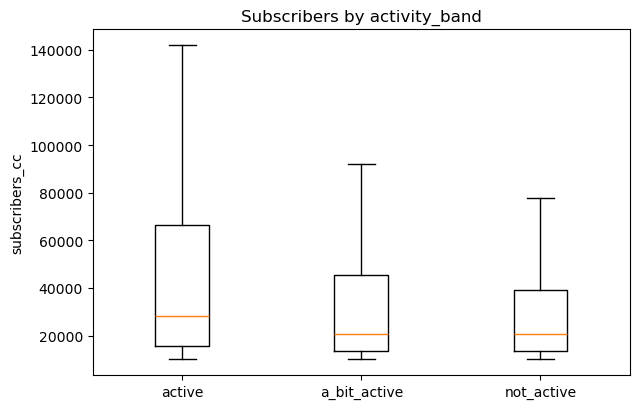

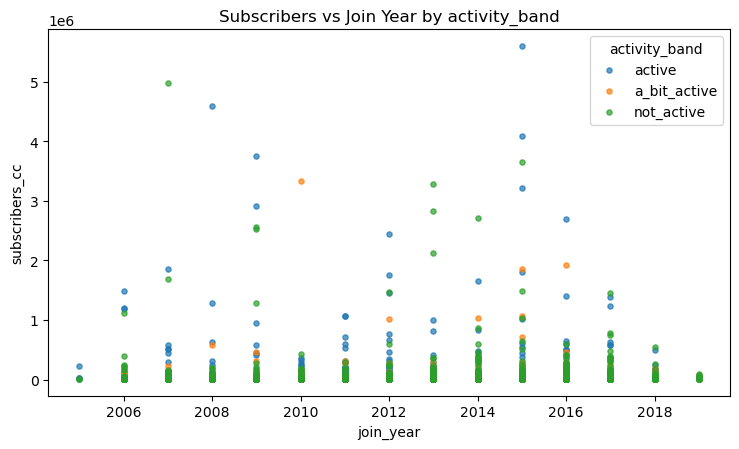

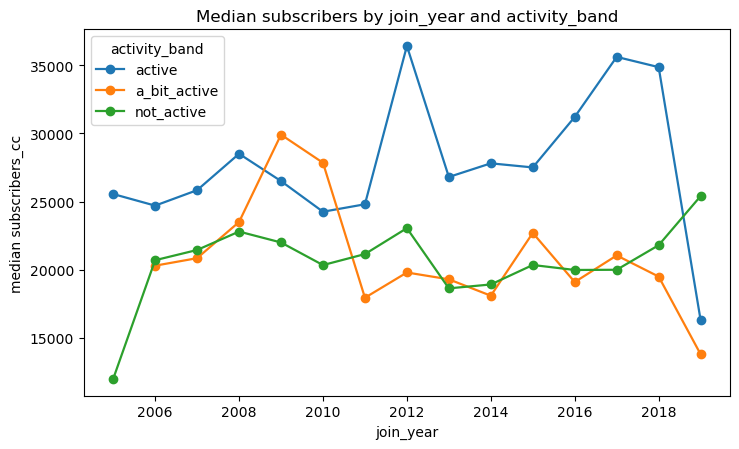

In [62]:
df_in = df.copy()
required = {"activity_band", "subscribers_cc", "join_date"}
missing = required - set(df_in.columns)
if missing:
    raise ValueError(f"df is missing columns: {missing}")

# ---- 2) clean types ----
df_in["activity_band"] = df_in["activity_band"].astype(str)
df_in["subscribers_cc"] = pd.to_numeric(df_in["subscribers_cc"], errors="coerce")
df_in["join_date"] = pd.to_datetime(df_in["join_date"], errors="coerce", utc=True)
df_in["join_year"] = df_in["join_date"].dt.year

# keep ordered bands
order = ["active", "a_bit_active", "not_active"]
df_in["activity_band"] = pd.Categorical(df_in["activity_band"], categories=order, ordered=True)

# drop rows lacking essentials
df_clean = df_in.dropna(subset=["activity_band", "subscribers_cc", "join_year"]).copy()

# ---- 3) summaries ----
summary_band = (
    df_clean.groupby("activity_band", observed=True)["subscribers_cc"]
    .agg(n="size", median="median", p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75))
    .reset_index()
)

summary_year_band = (
    df_clean.groupby(["join_year","activity_band"], observed=True)["subscribers_cc"]
    .agg(n="size", median="median", mean="mean")
    .reset_index()
    .sort_values(["join_year","activity_band"])
)

print("\n=== Subscribers by activity_band ===")
print(summary_band.to_string(index=False))
print("\n=== Subscribers by join_year × activity_band (median/mean) ===")
print(summary_year_band.head(20).to_string(index=False))

# ---- 5) Figure 1: Boxplot (subscribers by activity band; linear scale) ----
data = []
labels = []
for b in order:
    vals = df_clean.loc[df_clean["activity_band"] == b, "subscribers_cc"].dropna()
    if not vals.empty:
        data.append(vals.values)
        labels.append(b)
plt.figure(figsize=(6.5, 4.2))
plt.boxplot(data, labels=labels, showfliers=False)
plt.ylabel("subscribers_cc")
plt.title("Subscribers by activity_band")
plt.tight_layout()
plt.show()

# ---- 6) Figure 2: Scatter (join_year vs subscribers; one series per activity_band; linear scale) ----
plt.figure(figsize=(7.5, 4.6))
for b in order:
    sub = df_clean[df_clean["activity_band"] == b]
    if len(sub) == 0:
        continue
    plt.scatter(sub["join_year"], sub["subscribers_cc"], s=14, alpha=0.7, label=b)
plt.xlabel("join_year")
plt.ylabel("subscribers_cc")
plt.title("Subscribers vs Join Year by activity_band")
plt.legend(title="activity_band")
plt.tight_layout()
plt.show()

# ---- 7) Figure 3: Line (median subscribers by join_year, per band; linear scale) ----
med = (
    df_clean.groupby(["join_year","activity_band"], observed=True)["subscribers_cc"]
    .median()
    .reset_index()
)
plt.figure(figsize=(7.5, 4.6))
for b in order:
    sub = med[med["activity_band"] == b].sort_values("join_year")
    if len(sub) == 0:
        continue
    plt.plot(sub["join_year"], sub["subscribers_cc"], marker="o", linewidth=1.6, label=b)
plt.xlabel("join_year")
plt.ylabel("median subscribers_cc")
plt.title("Median subscribers by join_year and activity_band")
plt.legend(title="activity_band")
plt.tight_layout()
plt.show()

## 4-Get Relevant Category Metadata (Sports)

In [ ]:
path = base / "yt_metadata_en.jsonl.gz"
#config 1 -> Categories:
target = "Sports"
# *****************************
rows = []
for chunk in pd.read_json(path, lines=True, compression="gzip", chunksize=500_000):
    # handle either a list column 'categories' or a string column 'category'
    mask = ((chunk.get("categories", pd.Series([None]*len(chunk))) == target))
    rows.append(chunk.loc[mask])

df_sports = pd.concat(rows, ignore_index=True)

In [ ]:
out_path = Path("sports_yt_metadata_en.jsonl.gz")

with gzip.open(out_path, "wt", encoding="utf-8") as f:
    df_sports.to_json(f, orient="records", lines=True)

### 4.1-Select Relevant URLs for Sports

In [31]:
path = base / "urls.jsonl.gz"

ids = set(
    df_sports["display_id"].dropna().astype(str).unique().tolist()
)

rows = []
for chunk in pd.read_json(path, lines=True, compression="gzip",
                          chunksize=500_000, dtype={"display_id": str}):
    hits = chunk.loc[chunk["display_id"].astype(str).isin(ids)]
    if not hits.empty:
        rows.append(hits)

df_sport_urls = pd.concat(rows, ignore_index=True)

In [32]:
out_path = Path("sports_urls_metadata_en.jsonl.gz")

with gzip.open(out_path, "wt", encoding="utf-8") as f:
    df_sport_urls.to_json(f, orient="records", lines=True)

### 4.2-Read MetaData & Urls (Sports)

In [51]:
df_sports = pd.read_json("sports_yt_metadata_en.jsonl.gz", lines=True)
df_sport_urls = pd.read_json("sports_urls_metadata_en.jsonl.gz", lines=True)

In [67]:
(df_sport_urls.shape[0] / df_sports.shape[0])*100

59.53710856942338

In [79]:
df_sports_merged = df_sports.merge(df_sport_urls,on='display_id',how='inner')

In [81]:
df_sports_merged.shape

(2592491, 13)

In [109]:
df_sports_merged['dt'] = pd.to_datetime(df_sports_merged.upload_date)
df_sports_merged['year'] = df_sports_merged['dt'].dt.year

In [111]:
df_sports_merged.head(2)

,categories,channel_id,crawl_date,description,dislike_count,display_id,duration,like_count,tags,title,upload_date,view_count,urls,dt,year
0,Sports,UCzWn_gTaXyH5Idyo8Raf7_A,2019-11-03 16:39:58.773085,Are you ready to enter the high fashion world ...,78.0,Y1_pK68iSYQ,603,3305.0,"Catfishing,how to catch catfish,fishing,classy...",Classy Catfishing - How to Catch Catfish the P...,2019-09-28 00:00:00,58518.0,[https://www.youtube.com/playlist?list=PLdcvd_...,2019-09-28,2019
1,Sports,UCzWn_gTaXyH5Idyo8Raf7_A,2019-11-03 16:39:59.465346,Saltwater fishing out of Newquay Cornwall UK. ...,70.0,jF8TSo3ZfTc,1426,1889.0,"Fishing,Fishing uk,Angling,Sea angling,sea ang...",2 Day Saltwater Fishing Catch & Cook - UK Sea ...,2019-09-21 00:00:00,71998.0,"[https://youtu.be/PxVqfMBEbnM, https://youtu.b...",2019-09-21,2019


In [297]:
df_sports_merged.year.value_counts(normalize=True,dropna=False)*100

year
2018    22.159267
2019    17.760486
2017    16.877281
2016    12.671944
2015     9.949967
2014     6.932753
2013     5.589373
2012     3.773745
2011     2.008994
2010     1.054276
2009     0.707081
2008     0.352788
2007     0.131649
2006     0.030357
2005     0.000039
Name: proportion, dtype: float64

In [121]:
ids = set(df_sports_merged['display_id'].tolist())

In [123]:
df_sports_notmatched= df_sports.query("display_id not in @ids").reset_index(drop=True)

In [127]:
df_sports_notmatched['dt'] = pd.to_datetime(df_sports_notmatched.upload_date)
df_sports_notmatched['year'] = df_sports_notmatched['dt'].dt.year

In [129]:
df_sports_notmatched.year.value_counts(normalize=True,dropna=False)*100

year
2018    16.314182
2017    14.209491
2019    12.672418
2016    12.297373
2015    10.072756
2014     8.576151
2013     8.081974
2012     6.927552
2011     4.850615
2010     3.122444
2009     1.549332
2008     0.804917
2007     0.455753
2006     0.064929
2005     0.000114
Name: proportion, dtype: float64

### 4.3-Left Join & Amazon Filtering

In [133]:
df_sports_check = df_sports.merge(df_sport_urls,on='display_id',how='left')

In [135]:
df_sports_check.shape

(4354412, 13)

In [139]:
df_sports_check['checker']=np.where(df_sports_check['urls'].isna()==True,0,1)

In [145]:
df_sports_check['dt'] = pd.to_datetime(df_sports_check.upload_date)
df_sports_check['year'] = df_sports_check['dt'].dt.year

In [147]:
df_sports_check.head()

,categories,channel_id,crawl_date,description,dislike_count,display_id,duration,like_count,tags,title,upload_date,view_count,urls,checker,dt,year
0,Sports,UCzWn_gTaXyH5Idyo8Raf7_A,2019-11-03 16:39:57.427254,Can I catch 100 lbs of catfish LIVE. Me and Ja...,35.0,JOeSxtcNdHQ,8620,1673.0,"catfishing,fishing,fishing challenge,catfish,c...",Catching 100 lbs of Catfish 🔴Live,2019-10-01 00:00:00,48737.0,NaN,0,2019-10-01,2019
1,Sports,UCzWn_gTaXyH5Idyo8Raf7_A,2019-11-03 16:39:58.108323,,15.0,EPMLTw2zINw,355,1297.0,,big cat,2019-10-01 00:00:00,19999.0,NaN,0,2019-10-01,2019
2,Sports,UCzWn_gTaXyH5Idyo8Raf7_A,2019-11-03 16:39:58.773085,Are you ready to enter the high fashion world ...,78.0,Y1_pK68iSYQ,603,3305.0,"Catfishing,how to catch catfish,fishing,classy...",Classy Catfishing - How to Catch Catfish the P...,2019-09-28 00:00:00,58518.0,[https://www.youtube.com/playlist?list=PLdcvd_...,1,2019-09-28,2019
3,Sports,UCzWn_gTaXyH5Idyo8Raf7_A,2019-11-03 16:39:59.465346,Saltwater fishing out of Newquay Cornwall UK. ...,70.0,jF8TSo3ZfTc,1426,1889.0,"Fishing,Fishing uk,Angling,Sea angling,sea ang...",2 Day Saltwater Fishing Catch & Cook - UK Sea ...,2019-09-21 00:00:00,71998.0,"[https://youtu.be/PxVqfMBEbnM, https://youtu.b...",1,2019-09-21,2019
4,Sports,UCzWn_gTaXyH5Idyo8Raf7_A,2019-11-03 16:40:00.188768,My family spent 3 weeks touring England and fi...,73.0,Gp00dNaVouo,990,2699.0,"Fishing,catfish,wels catfish,how to catch catf...",How to Catch Wels Catfish - Fishing for Catfis...,2019-09-14 00:00:00,101924.0,"[https://youtu.be/SKZM-mkF6lg, https://youtu.b...",1,2019-09-14,2019


In [197]:
_AMZ = re.compile(
    r'(^|\.)amzn\.to$|(^|\.)amazon\.[a-z.]+$',
    flags=re.IGNORECASE
)

def is_amazon_domain(d: str) -> bool:
    if not isinstance(d, str):
        return False
    return bool(_AMZ.search(d.strip().lower()))
df_sports_check["n_amazon_domains"] = df_sports_check["domains"].apply(
    lambda lst: sum(1 for d in (lst or []) if is_amazon_domain(d))
)

df_sports_check["has_amazon"] = df_sports_check["n_amazon_domains"] > 0

def uniq_preserve(seq):
    seen = set(); out = []
    for x in seq:
        if x not in seen:
            seen.add(x); out.append(x)
    return out

df_sports_check["amazon_domains_unique"] = df_sports_check["domains"].apply(
    lambda lst: uniq_preserve([d for d in (lst or []) if is_amazon_domain(d)]))

In [276]:
#df_sports_check.dt()
#df_sports_check['mnth_yr'] = df_sports_check['dt'].apply(lambda x: x.strftime('%B-%Y')) 

In [280]:
df_sports_check.head()

,categories,channel_id,crawl_date,description,dislike_count,display_id,duration,like_count,tags,title,...,view_count,urls,checker,dt,year,domains,n_amazon_domains,has_amazon,amazon_domains_unique,mnth_yr
0,Sports,UCzWn_gTaXyH5Idyo8Raf7_A,2019-11-03 16:39:57.427254,Can I catch 100 lbs of catfish LIVE. Me and Ja...,35.0,JOeSxtcNdHQ,8620,1673.0,"catfishing,fishing,fishing challenge,catfish,c...",Catching 100 lbs of Catfish 🔴Live,...,48737.0,NaN,0,2019-10-01,2019,[],0,False,[],October-2019
1,Sports,UCzWn_gTaXyH5Idyo8Raf7_A,2019-11-03 16:39:58.108323,,15.0,EPMLTw2zINw,355,1297.0,,big cat,...,19999.0,NaN,0,2019-10-01,2019,[],0,False,[],October-2019
2,Sports,UCzWn_gTaXyH5Idyo8Raf7_A,2019-11-03 16:39:58.773085,Are you ready to enter the high fashion world ...,78.0,Y1_pK68iSYQ,603,3305.0,"Catfishing,how to catch catfish,fishing,classy...",Classy Catfishing - How to Catch Catfish the P...,...,58518.0,[https://www.youtube.com/playlist?list=PLdcvd_...,1,2019-09-28,2019,"[youtube.com, facebook.com, shop.spreadshirt.com]",0,False,[],September-2019
3,Sports,UCzWn_gTaXyH5Idyo8Raf7_A,2019-11-03 16:39:59.465346,Saltwater fishing out of Newquay Cornwall UK. ...,70.0,jF8TSo3ZfTc,1426,1889.0,"Fishing,Fishing uk,Angling,Sea angling,sea ang...",2 Day Saltwater Fishing Catch & Cook - UK Sea ...,...,71998.0,"[https://youtu.be/PxVqfMBEbnM, https://youtu.b...",1,2019-09-21,2019,"[youtu.be, youtu.be, youtu.be, newquayfishingt...",0,False,[],September-2019
4,Sports,UCzWn_gTaXyH5Idyo8Raf7_A,2019-11-03 16:40:00.188768,My family spent 3 weeks touring England and fi...,73.0,Gp00dNaVouo,990,2699.0,"Fishing,catfish,wels catfish,how to catch catf...",How to Catch Wels Catfish - Fishing for Catfis...,...,101924.0,"[https://youtu.be/SKZM-mkF6lg, https://youtu.b...",1,2019-09-14,2019,"[youtu.be, youtu.be, facebook.com, homefarmfis...",0,False,[],September-2019


In [291]:
df_sports_check.groupby("year")["checker"].value_counts(normalize=True).reset_index()
#yes-no

,year,checker,proportion
0,2005,0,0.666667
1,2005,1,0.333333
2,2006,0,0.592439
3,2006,1,0.407561
4,2007,0,0.701739
5,2007,1,0.298261
6,2008,0,0.607939
7,2008,1,0.392061
8,2009,0,0.598260
9,2009,1,0.401740


In [287]:
df_sports_check.query("checker==1").groupby("year")["has_amazon"].value_counts(normalize=False).reset_index()
#amazon

,year,has_amazon,count
0,2005,False,1
1,2006,False,743
2,2006,True,44
3,2007,False,3393
4,2007,True,20
5,2008,False,9083
6,2008,True,63
7,2009,False,18122
8,2009,True,209
9,2010,False,26849


### 4.4- Interactive Visualization

In [66]:
import plotly.graph_objects as go

# --- base data ---
rows = [
    (2008, 0, 14182),
    (2008, 1, 9146),
    (2009, 0, 27298),
    (2009, 1, 18331),
    (2010, 0, 55015),
    (2010, 1, 27332),
    (2011, 0, 85464),
    (2011, 1, 52083),
    (2012, 0, 122058),
    (2012, 1, 97834),
    (2013, 1, 144904),
    (2013, 0, 142398),
    (2014, 1, 179731),
    (2014, 0, 151105),
    (2015, 1, 257952),
    (2015, 0, 177474),
    (2016, 1, 328519),
    (2016, 0, 216670),
    (2017, 1, 437542),
    (2017, 0, 250360),
    (2018, 1, 574477),
    (2018, 0, 287443),
    (2019, 1, 460439),
    (2019, 0, 223278),
]
df = pd.DataFrame(rows, columns=["year", "has_url", "count"])
pivot = (df.pivot_table(index="year", columns="has_url", values="count", aggfunc="sum")
           .fillna(0).astype(int).rename(columns={0:"No URL",1:"Has URL"}).sort_index())
pivot["Total"] = pivot["No URL"] + pivot["Has URL"]

years = pivot.index.to_numpy()
totals = pivot["Total"].to_numpy()
no_counts = pivot["No URL"].to_numpy()
yes_counts = pivot["Has URL"].to_numpy()

# --- amazon subset ONLY within Has URL ---
subset_rows = [
    (2008, True, 63),
    (2009, False, 18122),
    (2009, True, 209),
    (2010, False, 26849),
    (2010, True, 483),
    (2011, False, 50784),
    (2011, True, 1299),
    (2012, False, 95457),
    (2012, True, 2377),
    (2013, False, 141561),
    (2013, True, 3343),
    (2014, False, 177382),
    (2014, True, 2349),
    (2015, False, 253933),
    (2015, True, 4019),
    (2016, False, 322214),
    (2016, True, 6305),
    (2017, False, 423475),
    (2017, True, 14067),
    (2018, False, 552768),
    (2018, True, 21709),
    (2019, False, 442737),
    (2019, True, 17702),
]
subdf = pd.DataFrame(subset_rows, columns=["year", "is_url", "value"])
amazon_url = {y: int(v) for y, v in subdf[subdf["is_url"] == True][["year","value"]].values}

# --- axes ---
xmin, xmax = years.min()-0.6, years.max()+0.6
ymin, ymax = 0, float(totals.max())*1.15

# --- normalized sizes ---
tmax = float(totals.max())
scale = np.sqrt(totals / (tmax + 1e-9))

rx_base_min, rx_base_max = 0.28, 0.60
ry_base_min, ry_base_max = (ymax-ymin)*0.018, (ymax-ymin)*0.090
rx = rx_base_min + (rx_base_max - rx_base_min) * scale
ry = ry_base_min + (ry_base_max - ry_base_min) * scale

size_min, size_max = 5, 18
dot_size = size_min + (size_max - size_min) * scale

DARK_GREEN = "#1b5e20"  # Has URL
PURPLE     = "#8e44ad"  # Not URL
ORANGE     = "#f39c12"  # Amazon within Has URL

def fan_points_outer_orange(cx, cy, rx, ry, share_url, amazon_share_in_url,
                            base_dot, n_rings=7, dots_per_ring=16):
    ring_ms = []
    for ring in range(n_rings):
        r_frac = (ring + 1) / n_rings
        m = int(dots_per_ring * (1 + 0.25 * r_frac))
        ring_ms.append((r_frac, m))
    total_url_dots = sum(int(round(share_url * m)) for _, m in ring_ms)
    r_outer, m_outer = ring_ms[-1]
    url_outer = int(round(share_url * m_outer))
    desired_orange = int(round(amazon_share_in_url * total_url_dots))
    k_orange_outer = min(max(desired_orange, 0), url_outer)

    ox, oy, os = [], [], []
    gx, gy, gs = [], [], []
    px, py, ps = [], [], []

    for idx_ring, (r_frac, m) in enumerate(ring_ms):
        thetas = np.linspace(np.pi, 0, m, endpoint=True)
        ring_size = base_dot * (1.10 - 0.65 * r_frac)
        k_url = int(round(share_url * m))

        for j, theta in enumerate(thetas):
            x = cx + rx * r_frac * np.cos(theta)
            y = cy + ry * r_frac * np.sin(theta)
            s = max(ring_size, 2.5)

            if j < k_url:
                if idx_ring == n_rings - 1 and j < k_orange_outer:
                    ox.append(x); oy.append(y); os.append(s * 1.2)
                else:
                    gx.append(x); gy.append(y); gs.append(s)
            else:
                px.append(x); py.append(y); ps.append(s)

    return (np.array(ox), np.array(oy), np.array(os),
            np.array(gx), np.array(gy), np.array(gs),
            np.array(px), np.array(py), np.array(ps))

# --- build figure ---
fig = go.Figure()

hover_texts = []
for y, total, n0, n1 in zip(years, totals, no_counts, yes_counts):
    yes_pct = 100.0*n1/total
    no_pct  = 100.0*n0/total
    a_url   = amazon_url.get(int(y), 0)
    a_pct_in_url = (a_url / n1 * 100) if n1 > 0 else 0.0
    hover_texts.append(
        f"<b>Year:</b> {y}<br>"
        f"<b>Total videos:</b> <b>{total:,}</b><br>"
        f"<span style='color:white'><b>Has URL:</b> <b>{n1:,}</b> ({yes_pct:.1f}%)</span><br>"
        f"<span style='color:white'><b>Not URL:</b> <b>{n0:,}</b> ({no_pct:.1f}%)</span><br>"
        f"<span style='color:white'><b>Amazon within Has URL:</b> <b>{a_url:,}</b> ({a_pct_in_url:.2f}%)</span>"
    )

fig.add_trace(go.Scatter(
    x=years, y=totals, mode="markers",
    marker=dict(size=8, color="rgba(0,0,0,0)"),
    hovertext=hover_texts, hoverinfo="text", showlegend=False
))

for cx, cy, rx_i, ry_i, n1, n0, total, s_i in zip(years, totals, rx, ry, yes_counts, no_counts, totals, dot_size):
    share_url = n1/total if total else 0.0
    amazon_count = amazon_url.get(int(cx), 0)
    amazon_share_in_url = min(amazon_count / n1, 1.0) if n1 > 0 else 0.0

    Ox, Oy, Os, Gx, Gy, Gs, Px, Py, Ps = fan_points_outer_orange(
        cx, cy, rx_i, ry_i, share_url=share_url, amazon_share_in_url=amazon_share_in_url,
        base_dot=float(s_i), n_rings=7, dots_per_ring=16
    )
    fig.add_trace(go.Scatter(x=Gx, y=Gy, mode="markers",
                             marker=dict(size=Gs, color=DARK_GREEN, line=dict(width=0)),
                             hoverinfo="skip", showlegend=False))
    fig.add_trace(go.Scatter(x=Px, y=Py, mode="markers",
                             marker=dict(size=Ps, color=PURPLE, line=dict(width=0)),
                             hoverinfo="skip", showlegend=False))
    fig.add_trace(go.Scatter(x=Ox, y=Oy, mode="markers",
                             marker=dict(size=Os, color="#f39c12", line=dict(width=1, color="white")),
                             hoverinfo="skip", showlegend=False))

# Left-aligned title + multi-line italic subhead
title_text = "Sports category videos over time: totals, URL share, and Amazon-within-URL"
sub_lines = [
    "Each cluster sits at (year, total videos).",
    "Dark green = videos with URLs; purple = without URLs.",
    "Within the URL dots, the orange outer ring highlights Amazon links.",
    "Cluster growth shows rising video counts; URL share grows over time."
]
subhead_html = "<br>".join(f"<em>{line}</em>" for line in sub_lines)

fig.update_layout(
    title={
        "text": f"{title_text}<br>{subhead_html}",
        "x": 0.0, "xanchor": "left"
    },
    xaxis_title="Year",
    yaxis_title="Number of videos",
    template="plotly_white",
    xaxis=dict(range=[xmin, xmax], tickmode="linear", dtick=1),
    yaxis=dict(range=[ymin, ymax], separatethousands=True),
    margin=dict(l=70, r=40, t=130, b=50)
)

out_path = base/"xy_radial_fans_left_aligned_multiline.html"
fig.write_html(out_path, include_plotlyjs="cdn", full_html=True)
out_path

PosixPath('/Users/es/Downloads/4650046_files/xy_radial_fans_left_aligned_multiline.html')

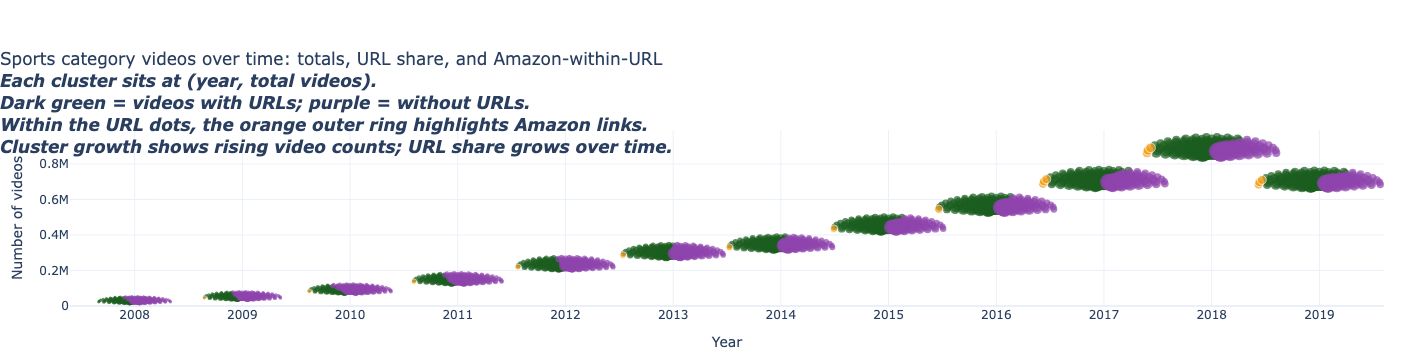

In [68]:
fig.show()

In [155]:
df_sports_check.year.value_counts()

year
2018    861920
2017    687902
2019    683717
2016    545189
2015    435426
2014    330836
2013    287302
2012    219892
2011    137547
2010     82347
2009     45629
2008     23328
2007     11443
2006      1931
2005         3
Name: count, dtype: int64

In [157]:
df_sports_check.groupby("year")['checker'].value_counts(normalize=False)

year  checker
2005  0               2
      1               1
2006  0            1144
      1             787
2007  0            8030
      1            3413
2008  0           14182
      1            9146
2009  0           27298
      1           18331
2010  0           55015
      1           27332
2011  0           85464
      1           52083
2012  0          122058
      1           97834
2013  1          144904
      0          142398
2014  1          179731
      0          151105
2015  1          257952
      0          177474
2016  1          328519
      0          216670
2017  1          437542
      0          250360
2018  1          574477
      0          287443
2019  1          460439
      0          223278
Name: count, dtype: int64

In [70]:
import json
from textwrap import dedent

amazon_rows = [
    (2008, False, 9083),
    (2008, True,    63),
    (2009, False, 18122),
    (2009, True,   209),
    (2010, False, 26849),
    (2010, True,   483),
    (2011, False, 50784),
    (2011, True,  1299),
    (2012, False, 95457),
    (2012, True,  2377),
    (2013, False,141561),
    (2013, True,  3343),
    (2014, False,177382),
    (2014, True,  2349),
    (2015, False,253933),
    (2015, True,  4019),
    (2016, False,322214),
    (2016, True,  6305),
    (2017, False,423475),
    (2017, True, 14067),
    (2018, False,552768),
    (2018, True, 21709),
    (2019, False,442737),
    (2019, True, 17702),
]
yes_no_rows = [
    (2008, 9146, 14182),
    (2009, 18331, 27298),
    (2010, 27332, 55015),
    (2011, 52083, 85464),
    (2012, 97834, 122058),
    (2013, 144904, 142398),
    (2014, 179731, 151105),
    (2015, 257952, 177474),
    (2016, 328519, 216670),
    (2017, 437542, 250360),
    (2018, 574477, 287443),
    (2019, 460439, 223278),
]

amz_true = {y: cnt for (y, is_amz, cnt) in amazon_rows if is_amz}

UNIT = 8_000
items = []
for y, yes, no in yes_no_rows:
    total = yes + no
    amz = min(amz_true.get(y, 0), yes)
    url_pct = 100 * yes / total if total else 0.0
    amz_pct_abs = 100 * amz / total if total else 0.0
    coins = (total + UNIT - 1) // UNIT
    items.append({
        "year": y, "total": total, "yes": yes, "no": no, "amz": amz,
        "url_pct": url_pct, "amz_pct_abs": amz_pct_abs, "coins": int(coins),
        "units_url": yes / UNIT, "units_amz": amz / UNIT
    })

DATA_JSON = json.dumps(items)

html = f"""<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1">
<title>Sports Category — Synchronized Panels & Plots (+ counting texts & totals)</title>
<style>
  :root{{
    --bg:#0e1630; --text:#e8eefb; --muted:#a9b5d9; --edge:#1b1f2f;
    --url:#2ecc71; --no:#ffffff; --amz:#f59e0b; --grayline:#6b7280;
    --coin:18px; --gap:6px; --panel-gap:14px;
    --step:1100ms;
  }}
  *{{box-sizing:border-box}} html,body{{height:100%}}
  body{{ margin:0; background:var(--bg); color:var(--text);
        font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Arial;
        display:flex; justify-content:center; }}
  .wrap{{ width:min(1200px, 98vw); padding:20px 14px 26px; }}
  h1{{ font-size:24px; font-weight:800; margin:0; letter-spacing:.4px; }}
  .subtitle{{ color:var(--muted); font-size:13px; margin:6px 0 12px; opacity:.9; }}

  .controls{{ display:flex; gap:10px; align-items:center; flex-wrap:wrap; margin-bottom: 10px; }}
  .btn{{ padding:7px 10px; border-radius:12px; border:1px solid #2b3553; background:#121a38; color:var(--text); cursor:pointer; }}
  .hint{{ margin-left:auto; color:var(--muted); font-size:12px; opacity:.95; }}

  .grid-all{{ display:grid; grid-template-columns: repeat(4, 1fr); gap: var(--panel-gap); align-items:start; }}
  .chart-card{{ grid-column: 1 / -1;
               background: radial-gradient(900px 380px at -10% 110%, rgba(255,255,255,.06), transparent 60%);
               box-shadow: 0 10px 30px rgba(0,0,0,.18) inset; border-radius:16px; padding:12px 14px; }}
  .chart-title{{ font-size:14px; color:var(--muted); margin-bottom:6px; display:flex; gap:10px; align-items:center; }}
  .chart{{ width:100%; height:260px; }}
  .chart.small{{ height:220px; }}

  .axis line, .axis path{{ stroke:#41507a; }}
  .axis text{{ fill:#cfd8f3; font-size:10px; }}

  .line.gray{{ fill:none; stroke:var(--grayline); stroke-width:1.6; stroke-linecap:round; opacity:.85; }}
  .ball{{ opacity:0; transform: translateY(6px) scale(.85); transition: transform .3s ease, opacity .3s ease; user-select:none; }}
  .ball.on{{ opacity:1; transform: translateY(0) scale(1); }}

  .line.amz{{ fill:none; stroke:var(--amz); stroke-width:2.4; stroke-linecap:round; }}
  .dot.amz{{ fill:var(--amz); stroke:#7a3d00; stroke-width:1.0; opacity:0; transition: opacity .3s; }}
  .dot.amz.on{{ opacity:1; }}

  .panel{{
    background: radial-gradient(900px 380px at -10% 110%, rgba(255,255,255,.06), transparent 60%);
    box-shadow: 0 10px 30px rgba(0,0,0,.18) inset;
    border-radius:14px; padding:10px 12px; min-height: 140px;
    transition: box-shadow .25s ease;
  }}
  .panel.active{{ box-shadow: 0 0 0 2px rgba(167,139,250,.6), 0 0 18px rgba(167,139,250,.35) inset; }}

  .p-head{{ display:flex; justify-content:space-between; align-items:flex-start; gap:8px; margin-bottom:6px; }}
  .year{{ font-weight:900; font-size:18px; letter-spacing:.4px; }}
  .meta{{ display:flex; flex-direction:column; align-items:flex-end; gap:2px; }}
  .row{{ font-size:12px; }}
  .row .urlc{{ color: var(--url); font-weight:700; }}
  .row .amzc{{ color: var(--amz); font-weight:700; }}

  .grid{{ display:grid; grid-template-columns: repeat(10, var(--coin)); grid-auto-rows: var(--coin); gap: var(--gap); place-items:center; }}

  .coin{{ width:var(--coin); height:var(--coin); }}
  .coin svg .rim{{ stroke:var(--edge); stroke-width:1.0; fill:var(--no); }}
  .coin svg .shine{{ fill:rgba(255,255,255,.12); }}
  .coin svg .dollar{{ fill:#0e1630; opacity:.9; font-weight:700; font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Arial; font-size:56px; }}
</style>
</head>
<body>
  <div class="wrap">
    <h1>Sports Category</h1>
    <div class="subtitle">YouTube Sports videos (2008–2019). Panels show totals per year; top plot shows share with any URL; bottom plot shows share with Amazon links. Derived from your df_sports + URL parsing.</div>

    <div class="controls">
      <button id="play" class="btn">Play ▶</button>
      <button id="pause" class="btn">Pause ⏸</button>
      <button id="restart" class="btn">Restart ↺</button>
      <div class="hint">1 coin = 8,000 videos</div>
    </div>

    <div class="grid-all">
      <!-- Top: URL% -->
      <div class="chart-card">
        <div class="chart-title">Percentage of videos with URLs</div>
        <svg id="chart_url" class="chart"></svg>
      </div>

      <!-- Middle: Panels with Coins -->
      <div id="panels" style="grid-column: 1 / -1; display:grid; grid-template-columns: repeat(4, 1fr); gap: 14px;"></div>

      <!-- Bottom: Amazon% -->
      <div class="chart-card">
        <div class="chart-title">Percentage of videos containing Amazon links</div>
        <svg id="chart_amz" class="chart small"></svg>
      </div>
    </div>
  </div>

<script>
  const ITEMS = {DATA_JSON};
  const STEP = 1100; // ms per year

  function coinSVG(uid){{
    return `
      <svg viewBox="0 0 100 100" aria-hidden="true">
        <defs>
          <clipPath id="clip_url_${{uid}}" clipPathUnits="objectBoundingBox">
            <rect id="rect_url_${{uid}}" x="0" y="0" width="0" height="1"></rect>
          </clipPath>
          <clipPath id="clip_amz_${{uid}}" clipPathUnits="objectBoundingBox">
            <rect id="rect_amz_${{uid}}" x="0" y="0" width="0" height="1"></rect>
          </clipPath>
        </defs>
        <!-- Base gray coin -->
        <circle class="rim" cx="50" cy="50" r="47"></circle>
        <ellipse class="shine" cx="38" cy="30" rx="18" ry="10"/>
        <!-- URL overlay (green) -->
        <g class="url" clip-path="url(#clip_url_${{uid}})">
          <circle cx="50" cy="50" r="47" fill="var(--url)"></circle>
          <ellipse class="shine" cx="38" cy="30" rx="18" ry="10"/>
          <text class="dollar" x="50" y="62" text-anchor="middle">$</text>
        </g>
        <!-- Amazon overlay (orange) -->
        <g class="amz" clip-path="url(#clip_amz_${{uid}})">
          <circle cx="50" cy="50" r="47" fill="var(--amz)"></circle>
          <ellipse class="shine" cx="38" cy="30" rx="18" ry="10"/>
          <text class="dollar" x="50" y="62" text-anchor="middle">$</text>
        </g>
      </svg>`;
  }}

  function buildPanels(){{
    const panelsEl = document.getElementById('panels');
    panelsEl.innerHTML = ITEMS.map((it, idx) => {{
      const totalTxt = `<span class="totalc" data-target="${{it.total}}">0</span> videos`;
      const urlTxt = `<span class="urlc" data-target="${{it.url_pct.toFixed(1)}}" data-dec="1">0.0% URL</span>`;
      const amzTxt = `<span class="amzc" data-target="${{it.amz_pct_abs.toFixed(2)}}" data-dec="2">0.00% Amazon</span>`;
      const coins = it.coins;
      let coinsHTML = '';
      for(let i=0;i<coins;i++){{
        const uid = `${{idx}}_${{i}}`;
        coinsHTML += `<div class="coin" data-uid="${{uid}}">${{coinSVG(uid)}}</div>`;
      }}
      return `
        <div class="panel" data-year="${{it.year}}" data-idx="${{idx}}" data-coins="${{coins}}">
          <div class="p-head">
            <div class="year">${{it.year}}</div>
            <div class="meta">
              <div class="row">${{totalTxt}}</div>
              <div class="row">${{urlTxt}}</div>
              <div class="row">${{amzTxt}}</div>
            </div>
          </div>
          <div class="grid">${{coinsHTML}}</div>
        </div>`;
    }}).join('');
  }}

  function sizeMap(val, vmin, vmax, pmin, pmax){{
    if(vmax === vmin) return (pmin + pmax)/2;
    const t = (val - vmin) / (vmax - vmin);
    return pmin + t*(pmax - pmin);
  }}

  function buildURLChart(){{
    const svg = document.getElementById('chart_url');
    const bounds = svg.getBoundingClientRect();
    const w = Math.max(700, Math.floor(bounds.width));
    const h = Math.max(260, Math.floor(bounds.height));
    svg.setAttribute('viewBox', `0 0 ${{w}} ${{h}}`);
    svg.innerHTML = '';
    const m = {{t:18, r:16, b:28, l:40}};
    const iw = w - m.l - m.r, ih = h - m.t - m.b;

    const xs = ITEMS.map(d=>d.year);
    const ys = ITEMS.map(d=>d.url_pct);
    const xmin = Math.min(...xs), xmax = Math.max(...xs);
    const ymin = 32, ymax = Math.ceil(Math.max(...ys)/5)*5;
    const X = year => m.l + ((year - xmin) / (xmax - xmin)) * iw;
    const Y = val  => m.t + ih - ((val - ymin) / (ymax - ymin)) * ih;

    // axes
    const gx = document.createElementNS('http://www.w3.org/2000/svg','g'); gx.setAttribute('class','axis');
    for(let yr = xmin; yr <= xmax; yr+=1){{
      const x = X(yr);
      gx.insertAdjacentHTML('beforeend', `<line x1="${{x}}" y1="${{m.t+ih}}" x2="${{x}}" y2="${{m.t+ih+4}}" />`);
      gx.insertAdjacentHTML('beforeend', `<text x="${{x}}" y="${{m.t+ih+18}}" text-anchor="middle">${{yr}}</text>`);
    }}
    const gy = document.createElementNS('http://www.w3.org/2000/svg','g'); gy.setAttribute('class','axis');
    for(let v=ymin; v<=ymax; v+=5){{
      const y = Y(v);
      gy.insertAdjacentHTML('beforeend', `<line x1="${{m.l-4}}" y1="${{y}}" x2="${{m.l}}" y2="${{y}}" />`);
      gy.insertAdjacentHTML('beforeend', `<text x="${{m.l-6}}" y="${{y+3}}" text-anchor="end">${{v}}%</text>`);
    }}
    svg.appendChild(gx); svg.appendChild(gy);

    // gray line
    const pts = xs.map((yr,i)=>`${{X(yr)}},${{Y(ys[i])}}`).join(' ');
    const path = document.createElementNS('http://www.w3.org/2000/svg','polyline');
    path.setAttribute('points', pts); path.setAttribute('class','line gray'); svg.appendChild(path);
    const L = path.getTotalLength ? path.getTotalLength() : 0;
    if(L){{ path.style.strokeDasharray = L; path.style.strokeDashoffset = L; path.dataset.totalLen = L; }}

    // balls
    const minPct = Math.min(...ys), maxPct = Math.max(...ys);
    xs.forEach((yr, i)=>{{
      const x = X(yr), y = Y(ys[i]);
      const fontSize = sizeMap(ys[i], minPct, maxPct, 16, 28);
      const t = document.createElementNS('http://www.w3.org/2000/svg','text');
      t.setAttribute('x', x); t.setAttribute('y', y+6); t.setAttribute('text-anchor','middle');
      t.setAttribute('class', 'ball'); t.setAttribute('data-idx', i);
      t.setAttribute('style', `font-size:${{fontSize}}px;`);
      t.textContent = '⚽';
      svg.appendChild(t);
    }});
  }}

  function buildAMZChart(){{
    const svg = document.getElementById('chart_amz');
    const bounds = svg.getBoundingClientRect();
    const w = Math.max(700, Math.floor(bounds.width));
    const h = Math.max(220, Math.floor(bounds.height));
    svg.setAttribute('viewBox', `0 0 ${{w}} ${{h}}`);
    svg.innerHTML = '';
    const m = {{t:18, r:16, b:28, l:40}};
    const iw = w - m.l - m.r, ih = h - m.t - m.b;

    const xs = ITEMS.map(d=>d.year);
    const ys = ITEMS.map(d=>d.amz_pct_abs);

    const xmin = Math.min(...xs), xmax = Math.max(...xs);
    const ymin = 0, ymax = 3;
    const X = year => m.l + ((year - xmin) / (xmax - xmin)) * iw;
    const Y = val  => m.t + ih - ((val - ymin) / (ymax - ymin)) * ih;

    // axes
    const gx = document.createElementNS('http://www.w3.org/2000/svg','g'); gx.setAttribute('class','axis');
    for(let yr = xmin; yr <= xmax; yr+=1){{
      const x = X(yr);
      gx.insertAdjacentHTML('beforeend', `<line x1="${{x}}" y1="${{m.t+ih}}" x2="${{x}}" y2="${{m.t+ih+4}}" />`);
      gx.insertAdjacentHTML('beforeend', `<text x="${{x}}" y="${{m.t+ih+18}}" text-anchor="middle">${{yr}}</text>`);
    }}
    const gy = document.createElementNS('http://www.w3.org/2000/svg','g'); gy.setAttribute('class','axis');
    for(let v=ymin; v<=ymax; v+=0.5){{
      const y = Y(v);
      gy.insertAdjacentHTML('beforeend', `<line x1="${{m.l-4}}" y1="${{y}}" x2="${{m.l}}" y2="${{y}}" />`);
      gy.insertAdjacentHTML('beforeend', `<text x="${{m.l-6}}" y="${{y+3}}" text-anchor="end">${{v.toFixed(1)}}%</text>`);
    }}
    svg.appendChild(gx); svg.appendChild(gy);

    // line
    const pts = xs.map((yr,i)=>`${{X(yr)}},${{Y(ys[i])}}`).join(' ');
    const path = document.createElementNS('http://www.w3.org/2000/svg','polyline');
    path.setAttribute('points', pts); path.setAttribute('class','line amz'); svg.appendChild(path);
    const L = path.getTotalLength ? path.getTotalLength() : 0;
    if(L){{ path.style.strokeDasharray = L; path.style.strokeDashoffset = L; path.dataset.totalLen = L; }}

    // dots
    xs.forEach((yr,i)=>{{
      const cx = X(yr), cy = Y(ys[i]);
      const dot = document.createElementNS('http://www.w3.org/2000/svg','circle');
      dot.setAttribute('cx', cx); dot.setAttribute('cy', cy); dot.setAttribute('r', 3.6);
      dot.setAttribute('class', 'dot amz'); dot.setAttribute('data-idx', i); svg.appendChild(dot);
    }});
  }}

  function tweenNumber(el, target, decimals, duration){{
    const start = performance.now();
    const from = 0;
    function fmt(v){{ return Number(v).toFixed(decimals); }}
    function step(now){{
      const t = Math.min(1, (now - start) / duration);
      const val = from + t * (target - from);
      const suffix = el.classList.contains('urlc') ? '% URL' : '% Amazon';
      el.textContent = `${{fmt(val)}}${{suffix}}`;
      if(t < 1){{ requestAnimationFrame(step); }}
    }}
    requestAnimationFrame(step);
  }}
  function tweenInt(el, target, duration){{
    const start = performance.now();
    const from = 0;
    function step(now){{
      const t = Math.min(1, (now - start) / duration);
      const val = Math.round(from + t * (target - from));
      el.textContent = val.toLocaleString();
      if(t < 1){{ requestAnimationFrame(step); }}
    }}
    requestAnimationFrame(step);
  }}

  function resetAll(){{
    const urlPath = document.querySelector('#chart_url .line.gray');
    if(urlPath && urlPath.getTotalLength){{ const L = urlPath.getTotalLength(); urlPath.style.transition='none'; urlPath.style.strokeDasharray=L; urlPath.style.strokeDashoffset=L; }}
    document.querySelectorAll('#chart_url .ball').forEach(b=>b.classList.remove('on'));
    const amzPath = document.querySelector('#chart_amz .line.amz');
    if(amzPath && amzPath.getTotalLength){{ const L2 = amzPath.getTotalLength(); amzPath.style.transition='none'; amzPath.style.strokeDasharray=L2; amzPath.style.strokeDashoffset=L2; }}
    document.querySelectorAll('#chart_amz .dot.amz').forEach(d=>d.classList.remove('on'));
    document.querySelectorAll('[id^="rect_url_"], [id^="rect_amz_"]').forEach(r => r.setAttribute('width','0'));
    document.querySelectorAll('.panel').forEach(p=>p.classList.remove('active'));
    document.querySelectorAll('.panel .totalc').forEach(el=> el.textContent = '0');
    document.querySelectorAll('.panel .urlc').forEach(el=> el.textContent = '0.0% URL');
    document.querySelectorAll('.panel .amzc').forEach(el=> el.textContent = '0.00% Amazon');
  }}

  function animateChartsTo(index){{
    const duration = 1100 - 150;
    const urlSvg = document.getElementById('chart_url');
    const urlPath = urlSvg.querySelector('.line.gray');
    const L = parseFloat(urlPath?.getTotalLength() || '0');
    if(L){{
      const frac = (index+1) / ITEMS.length;
      urlPath.style.transition = `stroke-dashoffset ${{duration}}ms cubic-bezier(.2,.65,.2,1)`;
      urlPath.style.strokeDashoffset = L * (1 - frac);
    }}
    const ball = urlSvg.querySelector(`.ball[data-idx="${{index}}"]`);
    if(ball) ball.classList.add('on');
    const amzSvg = document.getElementById('chart_amz');
    const amzPath = amzSvg.querySelector('.line.amz');
    const L2 = parseFloat(amzPath?.getTotalLength() || '0');
    if(L2){{
      const frac2 = (index+1) / ITEMS.length;
      amzPath.style.transition = `stroke-dashoffset ${{duration}}ms cubic-bezier(.2,.65,.2,1)`;
      amzPath.style.strokeDashoffset = L2 * (1 - frac2);
    }}
    const dot = amzSvg.querySelector(`.dot.amz[data-idx="${{index}}"]`);
    if(dot) dot.classList.add('on');
  }}

  function fillCoinsForIndex(index){{
    const panel = document.querySelector(`.panel[data-idx="${{index}}"]`);
    if(!panel) return;
    panel.classList.add('active');
    const year = parseInt(panel.getAttribute('data-year'));
    const rec = ITEMS.find(it => it.year === year);
    const units_url = rec.units_url, units_amz = rec.units_amz;
    const coins = Array.from(panel.querySelectorAll('.coin'));
    coins.forEach(c => {{
      const uid = c.getAttribute('data-uid');
      document.getElementById('rect_url_' + uid).setAttribute('width', '0');
      document.getElementById('rect_amz_' + uid).setAttribute('width', '0');
    }});
    const N = coins.length || 1;
    const duration = 1100 - 250;
    const delayPer = Math.max(8, Math.floor(duration / N));
    coins.forEach((c, i)=>{{
      const uid = c.getAttribute('data-uid');
      const urlW = Math.max(0, Math.min(1, units_url - i));
      const amzW = Math.max(0, Math.min(1, units_amz - i));
      setTimeout(()=>{{ document.getElementById('rect_url_' + uid).setAttribute('width', String(urlW)); }}, i*delayPer);
      setTimeout(()=>{{ document.getElementById('rect_amz_' + uid).setAttribute('width', String(amzW)); }}, i*delayPer + Math.min(120, delayPer));
    }});
    // Counters in sync
    const totalEl = panel.querySelector('.totalc');
    const urlEl = panel.querySelector('.urlc');
    const amzEl = panel.querySelector('.amzc');
    const totalTarget = parseInt(totalEl.getAttribute('data-target'), 10);
    const urlTarget = parseFloat(urlEl.getAttribute('data-target'));
    const amzTarget = parseFloat(amzEl.getAttribute('data-target'));
    tweenInt(totalEl, totalTarget, duration);
    tweenNumber(urlEl, urlTarget, 1, duration);
    tweenNumber(amzEl, amzTarget, 2, duration);
  }}

  function playSequence(){{
    resetAll();
    let base = 250;
    for(let i=0;i<ITEMS.length;i++){{ 
      setTimeout(((ii)=>()=>{{
        fillCoinsForIndex(ii);
        animateChartsTo(ii);
      }})(i), base);
      base += 1100;
    }}
  }}

  function init(){{
    buildPanels();
    buildURLChart();
    buildAMZChart();
    playSequence();
  }}

  document.addEventListener('DOMContentLoaded', init);
  document.getElementById('play').addEventListener('click', ()=>{{ playSequence(); }});
  document.getElementById('pause').addEventListener('click', ()=>{{ /* placeholder */ }});
  document.getElementById('restart').addEventListener('click', ()=>{{ playSequence(); }});
  window.addEventListener('resize', ()=>{{ buildURLChart(); buildAMZChart(); playSequence(); }});
</script>
</body>
</html>
"""

out_path = base/"sports_synced_panels_plots_animated_texts_totals.html"
with open(out_path, "w", encoding="utf-8") as f:
    f.write(html)

out_path

PosixPath('/Users/es/Downloads/4650046_files/sports_synced_panels_plots_animated_texts_totals.html')